In [12]:
!git pull

Already up to date.


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import string


from sklearn.model_selection import train_test_split

In [14]:
%cd C:/Users/arpit/spring-2026-deep-learning-fragmented-id-resolution

C:\Users\arpit\spring-2026-deep-learning-fragmented-id-resolution


In [17]:
!git checkout Pedro

error: Your local changes to the following files would be overwritten by checkout:
	Embedding types vs F1.ipynb
Please commit your changes or stash them before you switch branches.
Aborting


In [22]:
# Pull ncvoters.tsv from Pedro branch without overwriting
import subprocess
import os

# Extract the file from Pedro branch and save it locally
subprocess.run([
    'git', 'show', 'Pedro:data/raw/ncvoters.tsv'
], stdout=open('data/raw', 'w'), cwd='.')

print("✓ Extracted ncvoters.tsv from Pedro branch → data/raw/ncvoters_from_Pedro.tsv")

# Read the TSV files into the DataFrame
# Data Source Hasso Plattner Institut 
# NDPL - Non-duplicates
# DPL - Duplicates
# ncvoters - a snap shot of the snapshot: VR_Snapshot_20181106 
df_ncvoters = pd.read_csv(r'data/raw/ncvoters.tsv', sep='\t')
DPL = pd.read_csv(r'data/raw/ncvoters_DPL.tsv', sep='\t')
NDPL = pd.read_csv(r'data/raw/ncvoters_NDPL.tsv', sep='\t')

print(f"✓ Loaded ncvoters: {df_ncvoters.shape}")
print(f"✓ Loaded DPL: {DPL.shape}")
print(f"✓ Loaded NDPL: {NDPL.shape}")


✓ Extracted ncvoters.tsv from Pedro branch → data/raw/ncvoters_from_Pedro.tsv


FileNotFoundError: [Errno 2] No such file or directory: 'data/raw/ncvoters.tsv'

In [ ]:
# Preprocessing for our fragemented ID analysis 
# Selecting identifyer variables not related to voting
df_ncvoters_frag_ID = df_ncvoters[[
#Stable Identifiers
#Only to be used for labeling /evaluation only 
# / not as a model feature
    'id', 'ncid', 'voter_reg_num', 
# Primary Model features - Strongest features, Strong entropy, Essential for matching
    #many variable such as name prefx and sufx are sparse we can either use none for missing or 0/1
    'first_name', 'midl_name', 'last_name', 'name_sufx_cd',
    #other varaiabes
# Adress Similarity features - Address is the second strongest identity anchor, 
    # Street name especially high discriminative signal # Unit numbers distinguish household
    #many variable such as unit designator are sparse we can either use none for missing or 0/1
    'house_num', 'street_name', 'street_dir', 'street_type_cd', 'unit_designator', 'unit_num', 'zip_code', 'res_city_desc',
#other varaiabes
# Demographic agreement indicators - Moderate/Supporting Features 
    # these will help us reduce false matches # they are agreement indicators, low-weight similarity features
    #age group rather than age because grouped/bin age is more stable
    'age', 'age_group', 'sex', 'race_code', 'race_desc', 'ethnic_code', 'ethnic_desc', 'birth_place',
# #other varaiabes 
 'phone_num','area_cd'   
 ]]
# print("\nSelected variables 'A' and 'C':")
print(df_ncvoters_frag_ID)

             id      ncid  voter_reg_num first_name  midl_name   last_name  \
0           277  aa173006        9132930  domenique       anna   gramolini   
1           566  aa175613        9136375    deborah                  wells   
2          1369  aa188072        9155533       evan  nathaniel     workman   
3          1567  by580879        9157283     alyssa   danielle      marion   
4          1583   ax51253        9157299    lacosta       gail  williamson   
...         ...       ...            ...        ...        ...         ...   
14178  14181892   er19108          19163     jerome     wilson      crouse   
14179  14182849  bn333629          71381      james    richard      dayton   
14180  14183213   en51685          77917       noah    matthew      pardue   
14181  14183530   er32617          62638     krista    stanley  williamson   
14182  14183738   er30307          60328      chara       lane    o connor   

      name_sufx_cd  house_num           street_name street_dir 

In [ ]:
# Adding labels to DPL and NDPL
DPL['label'] = 1 
NDPL['label'] = 0


print(DPL.head(10))
print(NDPL.head(10))

        id1      id2  label
0  11401396   511079      1
1   3569312  9442163      1
2   3569312  9522852      1
3   3569312  9549525      1
4   9442163  9522852      1
5   9442163  9549525      1
6   9522852  9549525      1
7  12658910  3213055      1
8  12658910  3174121      1
9   3213055  3174121      1
        id1       id2  participation  label
0  11826037   3981077       0.428571      0
1  11914983   2089120       0.428571      0
2  10063200  14074062       0.428571      0
3  13740661  13779277       0.428571      0
4  12909240  12927497       0.428571      0
5  12496955  12523473       0.428571      0
6  10378846  10400866       0.428571      0
7  13145288   9989193       0.285714      0
8   9760941   9976890       0.285714      0
9   1027663    997075       0.285714      0


In [ ]:
#Merge Duplicate and Non Duplicate pairs
pairs = pd.concat([DPL, NDPL])

print(pairs.head(20))
print(pairs.tail(20))


         id1       id2  label  participation
0   11401396    511079      1            NaN
1    3569312   9442163      1            NaN
2    3569312   9522852      1            NaN
3    3569312   9549525      1            NaN
4    9442163   9522852      1            NaN
5    9442163   9549525      1            NaN
6    9522852   9549525      1            NaN
7   12658910   3213055      1            NaN
8   12658910   3174121      1            NaN
9    3213055   3174121      1            NaN
10   1033927   9114975      1            NaN
11   8655919    847046      1            NaN
12   3462484  10261176      1            NaN
13    383933   7826253      1            NaN
14   7092750   7022921      1            NaN
15   1658211   6300974      1            NaN
16   9167292    377059      1            NaN
17  13224692   3594362      1            NaN
18    222684   3714715      1            NaN
19    299592   9279844      1            NaN
            id1       id2  label  participation
98122  

In [ ]:
# merging ncvoters on DPL and NDPL
pairs = pairs.merge(
    df_ncvoters_frag_ID,
    left_on="id1",
    right_on="id",
    how="left"
)
print(pairs.info())
print(pairs.head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107961 entries, 0 to 107960
Data columns (total 29 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   id1              107961 non-null  int64  
 1   id2              107961 non-null  int64  
 2   label            107961 non-null  int64  
 3   participation    98142 non-null   float64
 4   id               107961 non-null  int64  
 5   ncid             107961 non-null  object 
 6   voter_reg_num    107961 non-null  int64  
 7   first_name       107961 non-null  object 
 8   midl_name        107961 non-null  object 
 9   last_name        107961 non-null  object 
 10  name_sufx_cd     107961 non-null  object 
 11  house_num        107961 non-null  int64  
 12  street_name      107961 non-null  object 
 13  street_dir       107961 non-null  object 
 14  street_type_cd   107961 non-null  object 
 15  unit_designator  107961 non-null  object 
 16  unit_num         107961 non-null  obje

In [ ]:
#merging id2 
pairs = pairs.merge(
    df_ncvoters_frag_ID,
    left_on="id2",
    right_on="id",
    how="left",
    suffixes=("_1", "_2")
)

print(pairs.info())
print(pairs.head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107961 entries, 0 to 107960
Data columns (total 54 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id1                107961 non-null  int64  
 1   id2                107961 non-null  int64  
 2   label              107961 non-null  int64  
 3   participation      98142 non-null   float64
 4   id_1               107961 non-null  int64  
 5   ncid_1             107961 non-null  object 
 6   voter_reg_num_1    107961 non-null  int64  
 7   first_name_1       107961 non-null  object 
 8   midl_name_1        107961 non-null  object 
 9   last_name_1        107961 non-null  object 
 10  name_sufx_cd_1     107961 non-null  object 
 11  house_num_1        107961 non-null  int64  
 12  street_name_1      107961 non-null  object 
 13  street_dir_1       107961 non-null  object 
 14  street_type_cd_1   107961 non-null  object 
 15  unit_designator_1  107961 non-null  object 
 16  un

Train Test Val Split

In [ ]:
import networkx as nx
from sklearn.model_selection import GroupShuffleSplit
from sklearn.model_selection import train_test_split 

# only duplicates
dup_pairs = pairs[pairs["label"] == 1]

G = nx.Graph()

# add edges
G.add_edges_from(zip(dup_pairs["id1"], dup_pairs["id2"]))

# connected components = entity clusters
components = list(nx.connected_components(G))

In [ ]:
# Adding ids back in data 

all_ids = set(df_ncvoters_frag_ID["id"])
ids_in_graph = set(G.nodes())

singletons = all_ids - ids_in_graph

for s in singletons:
    components.append({s})

In [ ]:
# Split

train_groups, temp_groups = train_test_split(
    components,
    test_size=0.3,
    random_state=42
)

val_groups, test_groups = train_test_split(
    temp_groups,
    test_size=0.5,
    random_state=42
)

In [ ]:
#Converting groups to ids 
train_ids = set().union(*train_groups)
val_ids   = set().union(*val_groups)
test_ids  = set().union(*test_groups)

In [ ]:
#bringing dups and non dups together

train_pairs = pairs[pairs["id1"].isin(train_ids) & pairs["id2"].isin(train_ids)]

val_pairs = pairs[pairs["id1"].isin(val_ids) & pairs["id2"].isin(val_ids)]

test_pairs = pairs[pairs["id1"].isin(test_ids) & pairs["id2"].isin(test_ids)]

In [ ]:
print("Train:", len(train_pairs))
print("Val:", len(val_pairs))
print("Test:", len(test_pairs))

Train: 54677
Val: 3573
Test: 3870


In [ ]:
print(df_ncvoters_frag_ID.columns)
print(pairs.columns)

print(train_pairs.columns)
print(val_pairs.columns)
print(test_pairs.columns)

Index(['id', 'ncid', 'voter_reg_num', 'first_name', 'midl_name', 'last_name',
       'name_sufx_cd', 'house_num', 'street_name', 'street_dir',
       'street_type_cd', 'unit_designator', 'unit_num', 'zip_code',
       'res_city_desc', 'age', 'age_group', 'sex', 'race_code', 'race_desc',
       'ethnic_code', 'ethnic_desc', 'birth_place', 'phone_num', 'area_cd'],
      dtype='object')
Index(['id1', 'id2', 'label', 'participation', 'id_1', 'ncid_1',
       'voter_reg_num_1', 'first_name_1', 'midl_name_1', 'last_name_1',
       'name_sufx_cd_1', 'house_num_1', 'street_name_1', 'street_dir_1',
       'street_type_cd_1', 'unit_designator_1', 'unit_num_1', 'zip_code_1',
       'res_city_desc_1', 'age_1', 'age_group_1', 'sex_1', 'race_code_1',
       'race_desc_1', 'ethnic_code_1', 'ethnic_desc_1', 'birth_place_1',
       'phone_num_1', 'area_cd_1', 'id_2', 'ncid_2', 'voter_reg_num_2',
       'first_name_2', 'midl_name_2', 'last_name_2', 'name_sufx_cd_2',
       'house_num_2', 'street_name_2'



 Augmented positives
 +  typos
  + nicknames
  + address abbreviation

 Hard negatives
  + same household
  + same same lastname
  + same firstname
  + suffix

Medium negative 
  + same first name negative  

Positives
  + same household
  + original duplicates
  +	typo duplicates
  + nickname duplicates
  + street abbreviation duplicates
  + multi-field duplicates

Negatives
 + household pairs
 + nickname negatives
 + suffix negatives
 + address formatting negatives


In [ ]:
#Creating a new variable id_to_clusters to be used in augmented training cell - #4 household negatives 
id_to_cluster = {}
for cluster_id, component in enumerate(components):
    for voter_id in component:
        id_to_cluster[voter_id] = cluster_id

# singletons
next_id = len(components)
for v_id in df_ncvoters_frag_ID["id"]:
    if v_id not in id_to_cluster:
        id_to_cluster[v_id] = next_id
        next_id += 1

print(f"Total IDs mapped: {len(id_to_cluster)}")

Total IDs mapped: 14183


In [ ]:
# 1. Utilities (names + street logic)

import random

nickname_dict = {
    "william": ["bill","billy","will"],
    "robert": ["bob","bobby","rob"],
    "james": ["jim","jimmy"],
    "john": ["jack","johnny"],
    "elizabeth": ["liz","beth","lizzy"],
    "margaret": ["maggie","meg","peggy"],
    "katherine": ["kate","kathy"],
    "sarah": ["sara"]
}

street_expand = {
    "st":"street",
    "rd":"road",
    "ave":"avenue",
    "dr":"drive",
    "ln":"lane",
    "blvd":"boulevard"
}

def nickname(name):
    n = str(name).lower()
    if n in nickname_dict:
        return random.choice(nickname_dict[n])
    for k,v in nickname_dict.items():
        if n in v:
            return k
    return name


def typo(name):
    name=list(str(name))
    if len(name)<3:
        return "".join(name)
    i=random.randint(0,len(name)-2)
    name[i],name[i+1]=name[i+1],name[i]
    return "".join(name)


def expand_street(st):
    s=str(st).lower()
    return street_expand.get(s,s)

    

In [ ]:

# 2. Duplicate augmentation (label = 1) - This creates multi-field realistic duplicates.

def augment_duplicates(train_pairs):
    augmented = []
    for _, row in train_pairs.iterrows():
        if row["label"] != 1:
            continue
        r = row.copy()
        side1_changed = False
        side2_changed = False

        if random.random() < 0.4:
            if random.random() < 0.5:
                r["first_name_1"] = typo(r["first_name_1"])
                side1_changed = True
            else:
                r["first_name_2"] = typo(r["first_name_2"])
                side2_changed = True

        if random.random() < 0.25:
            if not side1_changed and random.random() < 0.5:
                r["first_name_1"] = nickname(r["first_name_1"])
                side1_changed = True
            elif not side2_changed:
                r["first_name_2"] = nickname(r["first_name_2"])
                side2_changed = True

        if random.random() < 0.25:
            if not side1_changed:
                r["street_type_cd_1"] = expand_street(r["street_type_cd_1"])
            elif not side2_changed:
                r["street_type_cd_2"] = expand_street(r["street_type_cd_2"])

        augmented.append(r)
    return pd.DataFrame(augmented)

#aug_dups2 = augment_duplicates(train_pairs)
aug_dups2 = augment_duplicates(train_pairs)
print(aug_dups2.shape)
print(aug_dups2["first_name_1"].head())
print(train_pairs[train_pairs["label"]==1]["first_name_1"].head())

(6826, 54)
0       eric
1    seamje 
2    semjae 
3    semaje 
4     smaaje
Name: first_name_1, dtype: object
0       eric
1    semaje 
2    semaje 
3    semaje 
4     samaje
Name: first_name_1, dtype: object


In [ ]:
#3 adding steert_ type expansion in both direction 

def street_type_negatives(train_pairs, n=2000):
    pairs = []
    for _, row in train_pairs.sample(len(train_pairs)).iterrows():
        if row["label"] == 1:
            continue
        # skip if both street types are empty
        if row["street_type_cd_1"] == "" and row["street_type_cd_2"] == "":
            continue
        r = row.copy()
        if random.random() < 0.5:
            r["street_type_cd_1"] = expand_street(r["street_type_cd_1"])
        else:
            r["street_type_cd_2"] = expand_street(r["street_type_cd_2"])
        if r["street_type_cd_1"] != row["street_type_cd_1"] or \
           r["street_type_cd_2"] != row["street_type_cd_2"]:
            r["label"] = 0
            pairs.append(r)
        if len(pairs) >= n:
            break
    return pd.DataFrame(pairs)

In [ ]:
# ####We wanted: different people, same address --> confusing negative
#Reality:   same address → almost always same person in this dataset


# household_negatives isn't a useful hard negative generator for this specific dataset.
#  # 4. Hard negatives - We generate confusing but non-duplicate pairs. 
# # Household negatives (same address)
# # since this is being generated, I want to make sure to not accidentally append a known duplicate - cluster saftey
# def household_negatives(train_pairs,cluster_map, n=3000):

#     pairs=[]

#     groups=train_pairs.groupby(
#         ["house_num_1","street_name_1"]
#     )

#     for _,g in groups:

#         if len(g)<2:
#             continue

#         sample=g.sample(min(len(g),2))

#         r=sample.iloc[0].copy()

#         #cluster saftey check 
#         if cluster_map.get(sample.iloc[0]["id1"]) == cluster_map.get(sample.iloc[1]["id1"]):
#             continue

#         r["first_name_2"]=sample.iloc[1]["first_name_1"]
#         r["last_name_2"]=sample.iloc[1]["last_name_1"]

#         r["label"]=0
        

#         pairs.append(r)

#         if len(pairs)>=n:
#             break

#     return pd.DataFrame(pairs)

In [ ]:
#5 Nickname negatives 
#this simply adds nickname negatives by swapping some first names to nick names in the NDPL

def nickname_negatives(train_pairs,n=2000):

    pairs=[]

    for _,row in train_pairs.sample(len(train_pairs)).iterrows():
        if row["label"]==1: 
            continue

        r=row.copy()

        r["first_name_2"]=nickname(r["first_name_2"])

        if r["first_name_2"]!=row["first_name_2"]:

            r["label"]=0
            pairs.append(r)

        if len(pairs)>=n:
            break

    return pd.DataFrame(pairs)

In [ ]:
# # Suffix negatives Jr/Sr) - 0 in the negative data so this is meaningless it just would add noise and not signal 
# There 124 dups with suffixes — they're valid duplicates where one record has a missing suffix 
# #generating nonsensical suffix 
# def suffix_negatives(train_pairs,n=1000):

#     pairs=[]

#     for _,row in train_pairs.iterrows():
#          if row["label"] == 1:  # skip duplicates, work from negatives
#             continue
#         r=row.copy()

#         if pd.notna(row["name_sufx_cd_1"]):

#             r["name_sufx_cd_2"]="jr" if row["name_sufx_cd_1"]!="jr" else "sr"
#             r["label"]=0

#             pairs.append(r)

#         if len(pairs)>=n:
#             break

#     return pd.DataFrame(pairs)



Tested Suffix and it looks like it doesn't make sense to generate negative suffixes. 
* Because only dups would have junior-senior pairs. 
* could have non dups that are junior singleton and senior singleton. 
* the occurences of suffixes are sparse in our data
* we have 124 duplicate pairs with suffix mismatch -> valid raw data 

In [ ]:
# # Checking for confusable suffix cases in negatives
# confusable_negs = train_pairs[
#     (train_pairs["label"] == 0) &
#     (train_pairs["first_name_1"] == train_pairs["first_name_2"]) &
#     (train_pairs["last_name_1"] == train_pairs["last_name_2"]) &
#     (train_pairs["name_sufx_cd_1"] != train_pairs["name_sufx_cd_2"])
# ].shape[0]

# # Check confusable suffix cases in duplicates
# confusable_dups = train_pairs[
#     (train_pairs["label"] == 1) &
#     (train_pairs["first_name_1"] == train_pairs["first_name_2"]) &
#     (train_pairs["last_name_1"] == train_pairs["last_name_2"]) &
#     (train_pairs["name_sufx_cd_1"] != train_pairs["name_sufx_cd_2"])
# ].shape[0]

# print(f"Confusable suffix negatives: {confusable_negs}")
# print(f"Confusable suffix duplicates: {confusable_dups}")

# # Check how common suffixes are overall
# print(f"\nSuffix value counts id1:\n{train_pairs['name_sufx_cd_1'].value_counts()}")
# print(f"\nSuffix value counts id2:\n{train_pairs['name_sufx_cd_2'].value_counts()}")

In [ ]:
# #how many are missing suffixes on one side?
# # Verify - how many are just missing suffix on one side
# missing_one_side = suspicious[
#     (suspicious["name_sufx_cd_1"] == "") | 
#     (suspicious["name_sufx_cd_2"] == "")
# ].shape[0]

# actual_conflict = suspicious[
#     (suspicious["name_sufx_cd_1"] != "") & 
#     (suspicious["name_sufx_cd_2"] != "") &
#     (suspicious["name_sufx_cd_1"] != suspicious["name_sufx_cd_2"])
# ].shape[0]

# print(f"Missing suffix on one side: {missing_one_side}")
# print(f"Actual SR/JR conflicts: {actual_conflict}")

In [ ]:
# augmented training set 
aug_dups = augment_duplicates(train_pairs)

# hard 
street_neg = street_type_negatives(train_pairs)
#household_neg = household_negatives(train_pairs, id_to_cluster)
nickname_neg = nickname_negatives(train_pairs)

train_pairs_aug = pd.concat(
    [train_pairs,
     aug_dups, 
     street_neg,
    #household_neg, 
     nickname_neg],
    ignore_index=True
)

In [ ]:
#adding augmentation to val and test splits 
def augment_split(pairs):
    aug = augment_duplicates(pairs)
    street = street_type_negatives(pairs)
    nick = nickname_negatives(pairs)
    
    return pd.concat(
        [pairs, aug, street, nick],
        ignore_index=True
    )

# Apply consistently across all splits
# train_pairs_aug = augment_split(train_pairs)
val_pairs_aug   = augment_split(val_pairs)
test_pairs_aug  = augment_split(test_pairs)

Checking that all augmentations and hard negatives changes worked on TRAINING SET 

In [ ]:
# 1. Typo check - first_name should differ from original
typo_changes = aug_dups2[aug_dups2["first_name_1"] != train_pairs.loc[aug_dups2.index, "first_name_1"].values]
print(f"Typo applied to first_name_1: {len(typo_changes)}")

typo_changes2 = aug_dups2[aug_dups2["first_name_2"] != train_pairs.loc[aug_dups2.index, "first_name_2"].values]
print(f"Typo applied to first_name_2: {len(typo_changes2)}")

# 2. Nickname check - first_name should be in nickname dict values
nickname_changes1 = aug_dups2[aug_dups2["first_name_1"].str.lower().isin(
    [n for names in nickname_dict.values() for n in names] + list(nickname_dict.keys())
)]
print(f"Nickname in first_name_1: {len(nickname_changes1)}")

nickname_changes2 = aug_dups2[aug_dups2["first_name_2"].str.lower().isin(
    [n for names in nickname_dict.values() for n in names] + list(nickname_dict.keys())
)]
print(f"Nickname in first_name_2: {len(nickname_changes2)}")

# 3. Street expansion check - should see full words not abbreviations
expanded1 = aug_dups2[aug_dups2["street_type_cd_1"].isin(street_expand.values())]
print(f"Street expanded in street_type_cd_1: {len(expanded1)}")

expanded2 = aug_dups2[aug_dups2["street_type_cd_2"].isin(street_expand.values())]
print(f"Street expanded in street_type_cd_2: {len(expanded2)}")

# 4. Nickname negatives check
nick_negs = train_pairs_aug[
    (train_pairs_aug["label"] == 0) &
    (train_pairs_aug["first_name_2"].str.lower().isin(
        [n for names in nickname_dict.values() for n in names]
    ))
]
print(f"Nickname negatives: {len(nick_negs)}")

# 5. Street type negatives check
street_negs = train_pairs_aug[
    (train_pairs_aug["label"] == 0) &
    (train_pairs_aug["street_type_cd_1"].isin(street_expand.values()) |
     train_pairs_aug["street_type_cd_2"].isin(street_expand.values()))
]
print(f"Street type negatives: {len(street_negs)}")

# # 6. Household negatives check
# household_negs = train_pairs_aug[
#     (train_pairs_aug["label"] == 0) &
#     (train_pairs_aug["house_num_1"] == train_pairs_aug["house_num_2"]) &
#     (train_pairs_aug["street_name_1"] == train_pairs_aug["street_name_2"])
# ]
# print(f"Household negatives: {len(household_negs)}")

# 7. Overall label distribution
counts = train_pairs_aug["label"].value_counts()
pcts = train_pairs_aug["label"].value_counts(normalize=True) * 100
print(pd.DataFrame({"count": counts, "percentage": pcts.round(2)}))

Typo applied to first_name_1: 1370
Typo applied to first_name_2: 1356
Nickname in first_name_1: 434
Nickname in first_name_2: 435
Street expanded in street_type_cd_1: 962
Street expanded in street_type_cd_2: 298
Nickname negatives: 2300
Street type negatives: 2000
       count  percentage
label                   
0      51851       79.16
1      13652       20.84


In [ ]:
#How hard are our negatives?

# Check nickname negatives - how often do names match after nickname swap
nick_neg_rows = train_pairs_aug[
    (train_pairs_aug["label"] == 0) &
    (train_pairs_aug["first_name_2"].str.lower().isin(
        [n for names in nickname_dict.values() for n in names]
    ))
]

# How many have same last name - harder if last name also matches
same_last = (nick_neg_rows["last_name_1"] == nick_neg_rows["last_name_2"]).sum()
diff_last = (nick_neg_rows["last_name_1"] != nick_neg_rows["last_name_2"]).sum()

print(f"Nickname negatives with same last name: {same_last} ({same_last/len(nick_neg_rows)*100:.1f}%)")
print(f"Nickname negatives with different last name: {diff_last} ({diff_last/len(nick_neg_rows)*100:.1f}%)")

# Street negatives hardness
street_neg_rows = train_pairs_aug[
    (train_pairs_aug["label"] == 0) &
    (train_pairs_aug["street_type_cd_1"].isin(street_expand.values()) |
     train_pairs_aug["street_type_cd_2"].isin(street_expand.values()))
]

same_name = (
    (street_neg_rows["first_name_1"] == street_neg_rows["first_name_2"]) &
    (street_neg_rows["last_name_1"] == street_neg_rows["last_name_2"])
).sum()

print(f"\nStreet negatives with same full name: {same_name} ({same_name/len(street_neg_rows)*100:.1f}%)")

Nickname negatives with same last name: 9 (0.4%)
Nickname negatives with different last name: 2291 (99.6%)

Street negatives with same full name: 0 (0.0%)


In [ ]:
# do truly hard negatives even EXIST in our data? No

# Same last name + nickname first name pairs from different clusters
truly_hard = train_pairs[
    (train_pairs["label"] == 0) &
    (train_pairs["last_name_1"] == train_pairs["last_name_2"]) &
    (train_pairs["first_name_1"].str.lower().isin(nickname_dict.keys())) &
    (train_pairs["first_name_2"].str.lower().isin(
        [n for names in nickname_dict.values() for n in names]
    ))
]
print(f"Truly hard nickname negatives available: {len(truly_hard)}")

Truly hard nickname negatives available: 1


What actually differ in real duplicates 

* first_name: 139 differ (2.0%) <- almost never differs
* last_name: 965 differ (14.1%) <- Secondary signal 
* house_num: 6230 differ (91.3%)  <- Primary fragmentation signal 
* street_name: 6203 differ (90.9%) <- Primary fragmentation signal 
* street_type_cd: 5082 differ (74.5%) <- Stron signal

This tells us what we knew already from the EDA 
* duplicates in our dataset are primarily people who moved — same person, different address.
* and name changes (marraige, divorce) is a secondary signal


Our baseline features should heavily weight name similarity and treat address as a weak or noisy signal rather than a strong one. The fragmented ID problem in this dataset is fundamentally an address change detection problem, not a name variation problem. 



In [ ]:
# What actually differs between real duplicates
orig_dups = train_pairs[train_pairs["label"] == 1]
cols = ["first_name", "last_name", "house_num", "street_name", "street_type_cd"]

for col in cols:
    diff = (orig_dups[f"{col}_1"] != orig_dups[f"{col}_2"]).sum()
    pct = diff / len(orig_dups) * 100
    print(f"{col}: {diff} differ ({pct:.1f}%)")

first_name: 139 differ (2.0%)
last_name: 965 differ (14.1%)
house_num: 6230 differ (91.3%)
street_name: 6203 differ (90.9%)
street_type_cd: 5082 differ (74.5%)


In [ ]:
# # Check how many household pairs get rejected by cluster safety check
# groups = train_pairs.groupby(["house_num_1","street_name_1"])
# rejected = 0
# eligible = 0

# for _, g in groups:
#     if len(g) < 2:
#         continue
#     sample = g.sample(min(len(g), 2))
#     eligible += 1
#     if id_to_cluster.get(sample.iloc[0]["id1"]) == id_to_cluster.get(sample.iloc[1]["id1"]):
#         rejected += 1

# print(f"Eligible groups: {eligible}")
# print(f"Rejected by cluster safety check: {rejected}")
# print(f"Passed: {eligible - rejected}")

In [ ]:
# viewing augmentation results to make 
cols=[
"first_name_1","first_name_2",
"last_name_1","last_name_2",
"house_num_1","house_num_2",
"street_name_1","street_name_2",
"street_type_cd_1","street_type_cd_2",
"label" #, "age"
]

train_pairs_aug[cols].sample(40)

,first_name_1,first_name_2,last_name_1,last_name_2,house_num_1,house_num_2,street_name_1,street_name_2,street_type_cd_1,street_type_cd_2,label
913,ieisha,ieisha,simmons,simmons,6806,6806,bonita vista,bonita vista,ln,ln,1
41367,kathy,william,martin,ryder,1335,561,stacy rothrock,deaton young,rd,rd,0
44155,ayana,margarete,mclean,knox oats,706,473,cottingham,huckleberry,st,rd,0
59343,pamela,pamela,walker,walker,144,200,main,hall memorial,street,dr,1
11365,ernestine,lakisha,freas,davis,7495,109,brushy mountain,lincoln,rd,st,0
10438,robert,rita,thompson,ferguson,129,704,westover,thompson,dr,rd,0
47251,brenda,krista,martin,williamson,936,6701,eaton,nc 67,st,hwy,0
47905,jacob,grayson,edmund,freas,1629,7495,brook hollow,brushy mountain,dr,rd,0
24402,alice,virginia,mathews,lipps,5946,5330,woodhall,us hwy 19e,,,0
27844,deborah,leslie,sanders,jones,106,440,ashley,stroud,ave,rd,0


In [ ]:
#Checking for nonesensical dups
train_pairs[train_pairs.label==1][
["first_name_1","first_name_2","last_name_1","last_name_2"]
].sample(40)

,first_name_1,first_name_2,last_name_1,last_name_2
6016,danielle,danielle,barbour,smith
4134,deborah,deborah,hall,hall
9153,irene,irene,baver,bauer
7633,elvin,elvin,munn,munn
8681,brittany,brittany,bell,bell
3044,keith,keith,kaplan,kaplan
6567,michael,michael,krasuski,krasuski
448,emily,emily,nixon,clark
5234,abbington,abbington,pope,pope
8676,sarah,sarah,thornton,thornton


In [ ]:
# Check all columns are present in augmented data
print(aug_dups.columns.tolist())

# Spot check - view all fields for a few augmented records
aug_dups.sample(5).T  # .T transposes to see all fields vertically

['id1', 'id2', 'label', 'participation', 'id_1', 'ncid_1', 'voter_reg_num_1', 'first_name_1', 'midl_name_1', 'last_name_1', 'name_sufx_cd_1', 'house_num_1', 'street_name_1', 'street_dir_1', 'street_type_cd_1', 'unit_designator_1', 'unit_num_1', 'zip_code_1', 'res_city_desc_1', 'age_1', 'age_group_1', 'sex_1', 'race_code_1', 'race_desc_1', 'ethnic_code_1', 'ethnic_desc_1', 'birth_place_1', 'phone_num_1', 'area_cd_1', 'id_2', 'ncid_2', 'voter_reg_num_2', 'first_name_2', 'midl_name_2', 'last_name_2', 'name_sufx_cd_2', 'house_num_2', 'street_name_2', 'street_dir_2', 'street_type_cd_2', 'unit_designator_2', 'unit_num_2', 'zip_code_2', 'res_city_desc_2', 'age_2', 'age_group_2', 'sex_2', 'race_code_2', 'race_desc_2', 'ethnic_code_2', 'ethnic_desc_2', 'birth_place_2', 'phone_num_2', 'area_cd_2']


,4685,9709,7773,3097,1162
id1,601213,4114315,9820184,3585046,12799225
id2,664293,10599896,3710090,9115800,405269
label,1,1,1,1,1
participation,NaN,NaN,NaN,NaN,NaN
id_1,601213,4114315,9820184,3585046,12799225
ncid_1,al234855,bn478929,bl312201,bl212742,eh463826
voter_reg_num_1,331990,30252038,308779,685183,31105910
first_name_1,janet,brittany,alounthith,kenneth,michael
midl_name_1,ebbs,nichole,,alvin,a
last_name_1,kellett,good,phichith,hackney,bryant


In [ ]:
#applying across splits 
def augment_split(pairs):
    aug = augment_duplicates(pairs)
    street = street_type_negatives(pairs)
    nick = nickname_negatives(pairs)
    
    return pd.concat(
        [pairs, aug, street, nick],
        ignore_index=True
    )

# Apply consistently across all splits
#train_pairs_aug = augment_split(train_pairs)
val_pairs_aug   = augment_split(val_pairs)
test_pairs_aug  = augment_split(test_pairs)

Testing

In [ ]:
!pip install jellyfish

In [ ]:
from jellyfish import jaro_winkler_similarity

def build_features(pairs):
    features = pd.DataFrame()
    
    features["first_name_sim"] = pairs.apply(
        lambda r: jaro_winkler_similarity(
            str(r["first_name_1"]).lower(), 
            str(r["first_name_2"]).lower()
        ), axis=1
    )
    features["last_name_sim"] = pairs.apply(
        lambda r: jaro_winkler_similarity(
            str(r["last_name_1"]).lower(), 
            str(r["last_name_2"]).lower()
        ), axis=1
    )
    
    features["house_num_match"] = (pairs["house_num_1"] == pairs["house_num_2"]).astype(int)
    features["street_name_sim"] = pairs.apply(
        lambda r: jaro_winkler_similarity(
            str(r["street_name_1"]).lower(),
            str(r["street_name_2"]).lower()
        ), axis=1
    )
    features["street_type_match"] = (pairs["street_type_cd_1"] == pairs["street_type_cd_2"]).astype(int)
    
    return features

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

X_train = build_features(train_pairs_aug)
y_train = train_pairs_aug["label"]

X_val = build_features(val_pairs_aug)
y_val = val_pairs_aug["label"]

# X_test = build_features(test_pairs_aug)
# y_test = test_pairs_aug["label"]

model = LogisticRegression()
model.fit(X_train, y_train)

print("Val results:")
print(classification_report(y_val, model.predict(X_val)))

# print("Test results:")
# print(classification_report(y_test, model.predict(X_test)))

Val results:
              precision    recall  f1-score   support

           0       0.97      0.98      0.98      3969
           1       0.98      0.96      0.97      2938

    accuracy                           0.97      6907
   macro avg       0.97      0.97      0.97      6907
weighted avg       0.97      0.97      0.97      6907



In [ ]:
# from jellyfish import jaro_winkler_similarity

# def build_features(pairs):
#     features = pd.DataFrame()
    
#     # Name similarity - primary signal (almost never differs in real dups)
#     features["first_name_sim"] = pairs.apply(
#         lambda r: jaro_winkler_similarity(
#             str(r["first_name_1"]).lower(), 
#             str(r["first_name_2"]).lower()
#         ), axis=1
#     )
#     features["last_name_sim"] = pairs.apply(
#         lambda r: jaro_winkler_similarity(
#             str(r["last_name_1"]).lower(), 
#             str(r["last_name_2"]).lower()
#         ), axis=1
#     )
    
#     # Address similarity - noisy signal (91% differ in real dups)
#     features["house_num_match"] = (pairs["house_num_1"] == pairs["house_num_2"]).astype(int)
#     features["street_name_sim"] = pairs.apply(
#         lambda r: jaro_winkler_similarity(
#             str(r["street_name_1"]).lower(),
#             str(r["street_name_2"]).lower()
#         ), axis=1
#     )
#     features["street_type_match"] = (pairs["street_type_cd_1"] == pairs["street_type_cd_2"]).astype(int)
    
#     return features

In [ ]:
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import classification_report

# X_train = build_features(train_pairs_aug)
# y_train = train_pairs_aug["label"]

# X_val = build_features(val_pairs)
# y_val = val_pairs["label"]

# model = LogisticRegression()
# model.fit(X_train, y_train)

# y_pred = model.predict(X_val)
# print(classification_report(y_val, y_pred))

# # Check feature importance
# coefficients = pd.DataFrame({
#     "feature": X_train.columns,
#     "coefficient": model.coef_[0]
# }).sort_values("coefficient", ascending=False)
# print(coefficients)

In [ ]:
# print(val_pairs.shape)
# print(val_pairs["label"].value_counts(normalize=True))

In [ ]:
!git checkout Arpith

Your branch is up to date with 'origin/Arpith'.


Switched to branch 'Arpith'


In [ ]:
def cosine_sim(vec1, vec2):
    return np.dot(vec1, vec2) / (np.linalg.norm(vec1) * np.linalg.norm(vec2))


def get_similarity(row1, row2):
    vec1 = train_embed.loc[row1].values
    vec2 = train_embed.loc[row2].values
    return cosine_sim(vec1, vec2)

In [ ]:
train_last_name = train_pairs_aug[
    (train_pairs_aug['label'] == 1) & 
    (train_pairs_aug['last_name_1'] != train_pairs_aug['last_name_2']) | (train_pairs_aug['label'] == 0)
].copy()

print(f"Number of duplicate records with different last names: {len(train_last_name)}")
print("\nSample of duplicate records with different last names:")
print(train_last_name.head())

val_last_name = val_pairs_aug[
    (val_pairs_aug['label'] == 1) & 
    (val_pairs_aug['last_name_1'] != val_pairs_aug['last_name_2']) | (val_pairs_aug['label'] == 0)
].copy()
    
print(f"Number of validation records with different last names: {len(val_last_name)}")
print("\nSample of validation records with different last names:")
print(val_last_name.head())

train_dup_pairs = train_last_name[train_last_name['label'] == 1][['id1', 'id2']].copy()
train_ndup_pairs = train_last_name[train_last_name['label'] == 0][['id1', 'id2']].copy()
train_last_name_pairs = train_last_name[['id1', 'id2', 'label']].copy()

train_last_name_pairs

Number of duplicate records with different last names: 53781

Sample of duplicate records with different last names:
         id1       id2  label  participation      id_1     ncid_1  \
11   8655919    847046      1            NaN   8655919    am63944   
13    383933   7826253      1            NaN    383933   cw301593   
31  13322968  13275499      1            NaN  13322968  eh1062909   
32  13322968  13053815      1            NaN  13322968  eh1062909   
34   6943500   2266695      1            NaN   6943500    cm23978   

    voter_reg_num_1 first_name_1 midl_name_1 last_name_1  ... age_2  \
11        999971927      jillian    mitchell     trotter  ...    36   
13        600064667         lisa    marshall       huber  ...    60   
31          9917872     shaletta           d  washington  ...    55   
32          9917872     shaletta           d  washington  ...    55   
34            27798       pattie           b        king  ...    69   

    age_group_2   sex_2 race_code_2      

,id1,id2,label
11,8655919,847046,1
13,383933,7826253,1
31,13322968,13275499,1
32,13322968,13053815,1
34,6943500,2266695,1
...,...,...,...
65498,305179,7088630,0
65499,11511493,8027543,0
65500,2038708,474129,0
65501,10319837,2499428,0


In [ ]:
train_pairs_aug

In [ ]:
train_pairs_aug

Index(['id1', 'id2', 'label', 'participation', 'id_1', 'ncid_1',
       'voter_reg_num_1', 'first_name_1', 'midl_name_1', 'last_name_1',
       'name_sufx_cd_1', 'house_num_1', 'street_name_1', 'street_dir_1',
       'street_type_cd_1', 'unit_designator_1', 'unit_num_1', 'zip_code_1',
       'res_city_desc_1', 'age_1', 'age_group_1', 'sex_1', 'race_code_1',
       'race_desc_1', 'ethnic_code_1', 'ethnic_desc_1', 'birth_place_1',
       'phone_num_1', 'area_cd_1', 'id_2', 'ncid_2', 'voter_reg_num_2',
       'first_name_2', 'midl_name_2', 'last_name_2', 'name_sufx_cd_2',
       'house_num_2', 'street_name_2', 'street_dir_2', 'street_type_cd_2',
       'unit_designator_2', 'unit_num_2', 'zip_code_2', 'res_city_desc_2',
       'age_2', 'age_group_2', 'sex_2', 'race_code_2', 'race_desc_2',
       'ethnic_code_2', 'ethnic_desc_2', 'birth_place_2', 'phone_num_2',
       'area_cd_2'],
      dtype='object')

In [ ]:
train_id1_data = train_pairs_aug[
    ['id_1', 'first_name_1', 'midl_name_1', 'last_name_1', 'age_1', 'sex_1', 'area_cd_1', 'zip_code_1', 'street_name_1', 'house_num_1', 'area_cd_1']
].rename(columns={
    'id_1': 'id',
    'first_name_1': 'first_name',
    'midl_name_1': 'middle_name',
    'last_name_1': 'last_name',
    'age_1': 'age',
    'sex_1': 'sex',
    'area_cd_1': 'district',
    'zip_code_1': 'zipcode',
    'street_name_1': 'street',
    'house_num_1': 'house_num',
    'area_cd_1':'area_cd'
    
})

train_id2_data = train_pairs_aug[
    ['id_2', 'first_name_2', 'midl_name_2', 'last_name_2', 'age_2', 'sex_2', 'area_cd_2', 'zip_code_2', 'street_name_2','house_num_2', 'area_cd_2']
].rename(columns={
    'id_2': 'id',
    'first_name_2': 'first_name',
    'midl_name_2': 'middle_name',
    'last_name_2': 'last_name',
    'age_2': 'age',
    'sex_2': 'sex',
    'area_cd_2': 'district',
    'zip_code_2': 'zipcode',
    'street_name_2': 'street',
    'house_num_2': 'house_num',
    'area_cd_2':'area_cd'
})

val_id1_data = val_pairs_aug[
    ['id_1', 'first_name_1', 'midl_name_1', 'last_name_1', 'age_1', 'sex_1', 'area_cd_1', 'zip_code_1', 'street_name_1','house_num_1','area_cd_1']
].rename(columns={
    'id_1': 'id',
    'first_name_1': 'first_name',
    'midl_name_1': 'middle_name',
    'last_name_1': 'last_name',
    'age_1': 'age',
    'sex_1': 'sex',
    'area_cd_1': 'district',
    'zip_code_1': 'zipcode',
    'street_name_1': 'street',
    'house_num_1': 'house_num',
    'area_cd_1':'area_cd'
})

val_id2_data = val_pairs_aug[
    ['id_2', 'first_name_2', 'midl_name_2', 'last_name_2', 'age_2', 'sex_2', 'area_cd_2', 'zip_code_2', 'street_name_2','house_num_2', 'area_cd_2']
].rename(columns={
    'id_2': 'id',
    'first_name_2': 'first_name',
    'midl_name_2': 'middle_name',
    'last_name_2': 'last_name',
    'age_2': 'age',
    'sex_2': 'sex',
    'area_cd_2': 'district',
    'zip_code_2': 'zipcode',
    'street_name_2': 'street',
    'house_num_2': 'house_num',
    'area_cd_2':'area_cd'
})

train_ids_data = pd.concat([train_id1_data, train_id2_data], ignore_index=True).drop_duplicates(subset=['id'], keep='first')
val_ids_data = pd.concat([val_id1_data, val_id2_data], ignore_index=True).drop_duplicates(subset=['id'], keep='first')

train_ids_data['middle_name'] = train_ids_data['middle_name'].fillna("")
val_ids_data['middle_name'] = val_ids_data['middle_name'].fillna("")

print(train_ids_data.head())
print(val_ids_data.head())
print(train_ids_data.columns.tolist())

NameError: name 'train_pairs_aug' is not defined

In [ ]:
%cd C:\Users\arpit\spring-2026-deep-learning-fragmented-id-resolution\src

C:\Users\arpit\spring-2026-deep-learning-fragmented-id-resolution\src


In [ ]:
from src.model import CharCNNEncoder
from src import model
from src import model_utils
from src.model_utils import get_embeddings, cosine_sim

In [ ]:
def evaluate_model(ids_data, pairs_data, vocab_size=38, embed_dim=32, num_filters=128, 
                   kernel_sizes=(3, 4, 5), dropout=0.3, output_dim=128, thresholds=None):
    """
    Evaluate embedding model with given parameters.
    
    Parameters:
    -----------
    ids_data : pd.DataFrame
        DataFrame with columns: id, first_name, middle_name, last_name, age, sex
    pairs_data : pd.DataFrame
        DataFrame with columns: id1, id2, label (1 for duplicate, 0 for non-duplicate)
    vocab_size : int
        Vocabulary size for character mapping
    embed_dim : int
        Character embedding dimension
    num_filters : int
        Number of CNN filters
    kernel_sizes : tuple
        Kernel sizes for CNN
    dropout : float
        Dropout rate
    output_dim : int
        Output embedding dimension
    thresholds : list
        Thresholds to evaluate (default: [0.92, 0.94, 0.96, 0.97, 0.975, 0.98, 0.99])
    
    Returns:
    --------
    dict with keys:
        - 'embeddings': Generated embeddings dataframe
        - 'similarities': Dataframe with pairs and their similarity scores
        - 'metrics_df': Metrics at each threshold
        - 'best_f1': Best F1 score
        - 'best_threshold': Threshold with best F1
    """
    if thresholds is None:
        thresholds = np.linspace(0.985,1.00,10)
    
    print("=" * 60)
    print(f"Model Configuration:")
    print(f"  vocab_size={vocab_size}, embed_dim={embed_dim}")
    print(f"  num_filters={num_filters}, kernel_sizes={kernel_sizes}")
    print(f"  dropout={dropout}, output_dim={output_dim}")
    print("=" * 60)
    
    # Create model
    model_eval = CharCNNEncoder(
        vocab_size=vocab_size,
        embed_dim=embed_dim,
        num_filters=num_filters,
        kernel_sizes=kernel_sizes,
        dropout=dropout,
        output_dim=output_dim
    )
    
    # Generate embeddings
    print("\n1. Generating embeddings...")
    embeddings = get_embeddings(ids_data, model_eval)
    embeddings_indexed = embeddings.set_index('id')
    print(f"   ✓ Generated embeddings shape: {embeddings.shape}")
    print(f"   ✓ NaN values: {embeddings.isnull().sum().sum()}")
    
    # Compute similarities
    print("\n2. Computing similarities...")
    similarities = []
    for idx, row in pairs_data.iterrows():
        id1, id2 = row['id1'], row['id2']
        try:
            vec1 = embeddings_indexed.loc[id1].values
            vec2 = embeddings_indexed.loc[id2].values
            sim = np.dot(vec1, vec2) / (np.linalg.norm(vec1) * np.linalg.norm(vec2))
            similarities.append(sim)
        except KeyError:
            similarities.append(np.nan)
    
    pairs_with_sim = pairs_data.copy()
    pairs_with_sim['similarity'] = similarities
    print(f"   ✓ Computed {len(pairs_with_sim)} pair similarities")
    print(f"   ✓ Missing values: {pairs_with_sim['similarity'].isnull().sum()}")
    
    # Separate by label
    dup_sims = pairs_with_sim[pairs_with_sim['label'] == 1]['similarity'].dropna()
    ndup_sims = pairs_with_sim[pairs_with_sim['label'] == 0]['similarity'].dropna()
    
    print(f"\n3. Similarity Statistics:")
    print(f"   Duplicates (n={len(dup_sims)}): mean={dup_sims.mean():.4f}, std={dup_sims.std():.4f}")
    print(f"   Non-dups (n={len(ndup_sims)}): mean={ndup_sims.mean():.4f}, std={ndup_sims.std():.4f}")
    
    # Evaluate thresholds
    print(f"\n4. Evaluating thresholds...")
    metrics_results = []
    for thresh in thresholds:
        predictions = (pairs_with_sim['similarity'] > thresh).astype(int)
        actuals = pairs_with_sim['label'].astype(int)
        
        tn, fp, fn, tp = confusion_matrix(actuals, predictions).ravel()
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        accuracy = (tp + tn) / (tp + tn + fp + fn)
        
        metrics_results.append({
            'Threshold': thresh,
            'Precision': precision,
            'Recall': recall,
            'F1': f1,
            'Accuracy': accuracy,
            'TP': tp,
            'FP': fp,
            'FN': fn,
            'TN': tn
        })
    
    metrics_df = pd.DataFrame(metrics_results)
    best_f1_idx = metrics_df['F1'].idxmax()
    best_f1 = metrics_df.loc[best_f1_idx, 'F1']
    best_threshold = metrics_df.loc[best_f1_idx, 'Threshold']
    
    print(f"\n   Best F1: {best_f1:.4f} at threshold {best_threshold:.3f}")
    
    # Create visualizations
    print(f"\n5. Creating visualizations...")
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))
    
    # Histogram
    ax1.hist(dup_sims, bins=50, alpha=0.6, label='Duplicates', color='green', edgecolor='black')
    ax1.hist(ndup_sims, bins=50, alpha=0.6, label='Non-Duplicates', color='red', edgecolor='black')
    ax1.set_xlabel('Cosine Similarity', fontsize=11)
    ax1.set_ylabel('Frequency', fontsize=11)
    ax1.set_title('Distribution of Embedding Similarities', fontsize=12, fontweight='bold')
    ax1.legend()
    ax1.grid(alpha=0.3)
    
    # Precision-Recall Curve
    precisions_pr, recalls_pr, _ = precision_recall_curve(
        pairs_with_sim['label'].astype(int),
        pairs_with_sim['similarity']
    )
    ax2.plot(recalls_pr, precisions_pr, linewidth=2, color='blue')
    ax2.scatter(metrics_df['Recall'], metrics_df['Precision'], c=metrics_df['Threshold'], 
                cmap='viridis', s=100, zorder=5)
    ax2.set_xlabel('Recall', fontsize=11)
    ax2.set_ylabel('Precision', fontsize=11)
    ax2.set_title('Precision-Recall Curve', fontsize=12, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    
    # F1 vs Threshold
    ax3.plot(metrics_df['Threshold'], metrics_df['F1'], 'o-', linewidth=2, 
             markersize=8, label='F1', color='blue')
    ax3.plot(metrics_df['Threshold'], metrics_df['Precision'], 's-', linewidth=2, 
             markersize=6, label='Precision', color='orange')
    ax3.plot(metrics_df['Threshold'], metrics_df['Recall'], '^-', linewidth=2, 
             markersize=6, label='Recall', color='green')
    ax3.axvline(best_threshold, color='red', linestyle='--', alpha=0.7, label='Best F1')
    ax3.set_xlabel('Threshold', fontsize=11)
    ax3.set_ylabel('Score', fontsize=11)
    ax3.set_title('Metrics vs Similarity Threshold', fontsize=12, fontweight='bold')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # Confusion Matrix at best threshold
    best_preds = (pairs_with_sim['similarity'] > best_threshold).astype(int)
    best_cm = confusion_matrix(pairs_with_sim['label'].astype(int), best_preds)
    sns.heatmap(best_cm, annot=True, fmt='d', cmap='Blues', ax=ax4, cbar=False,
                xticklabels=['Non-Dup', 'Dup'], yticklabels=['Non-Dup', 'Dup'])
    ax4.set_ylabel('Actual', fontsize=11)
    ax4.set_xlabel('Predicted', fontsize=11)
    ax4.set_title(f'Confusion Matrix (threshold={best_threshold:.3f}, F1={best_f1:.4f})', 
                  fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n" + "=" * 60)
    print("THRESHOLD EVALUATION RESULTS:")
    print("=" * 60)
    print(metrics_df.to_string(index=False))
    print("=" * 60)
    
    return {
        'embeddings': embeddings,
        'similarities': pairs_with_sim,
        'metrics_df': metrics_df,
        'best_f1': best_f1,
        'best_threshold': best_threshold,
        'dup_sims': dup_sims,
        'ndup_sims': ndup_sims
    }

Evaluating embed_dim=8, output_dim=16
Model Configuration:
  vocab_size=38, embed_dim=8
  num_filters=128, kernel_sizes=(3, 4, 5)
  dropout=0.3, output_dim=16

1. Generating embeddings...
   ✓ Generated embeddings shape: (9750, 17)
   ✓ NaN values: 0

2. Computing similarities...
   ✓ Computed 53781 pair similarities
   ✓ Missing values: 0

3. Similarity Statistics:
   Duplicates (n=1930): mean=0.9932, std=0.0035
   Non-dups (n=51851): mean=0.9896, std=0.0042

4. Evaluating thresholds...

   Best F1: 0.2141 at threshold 0.995

5. Creating visualizations...


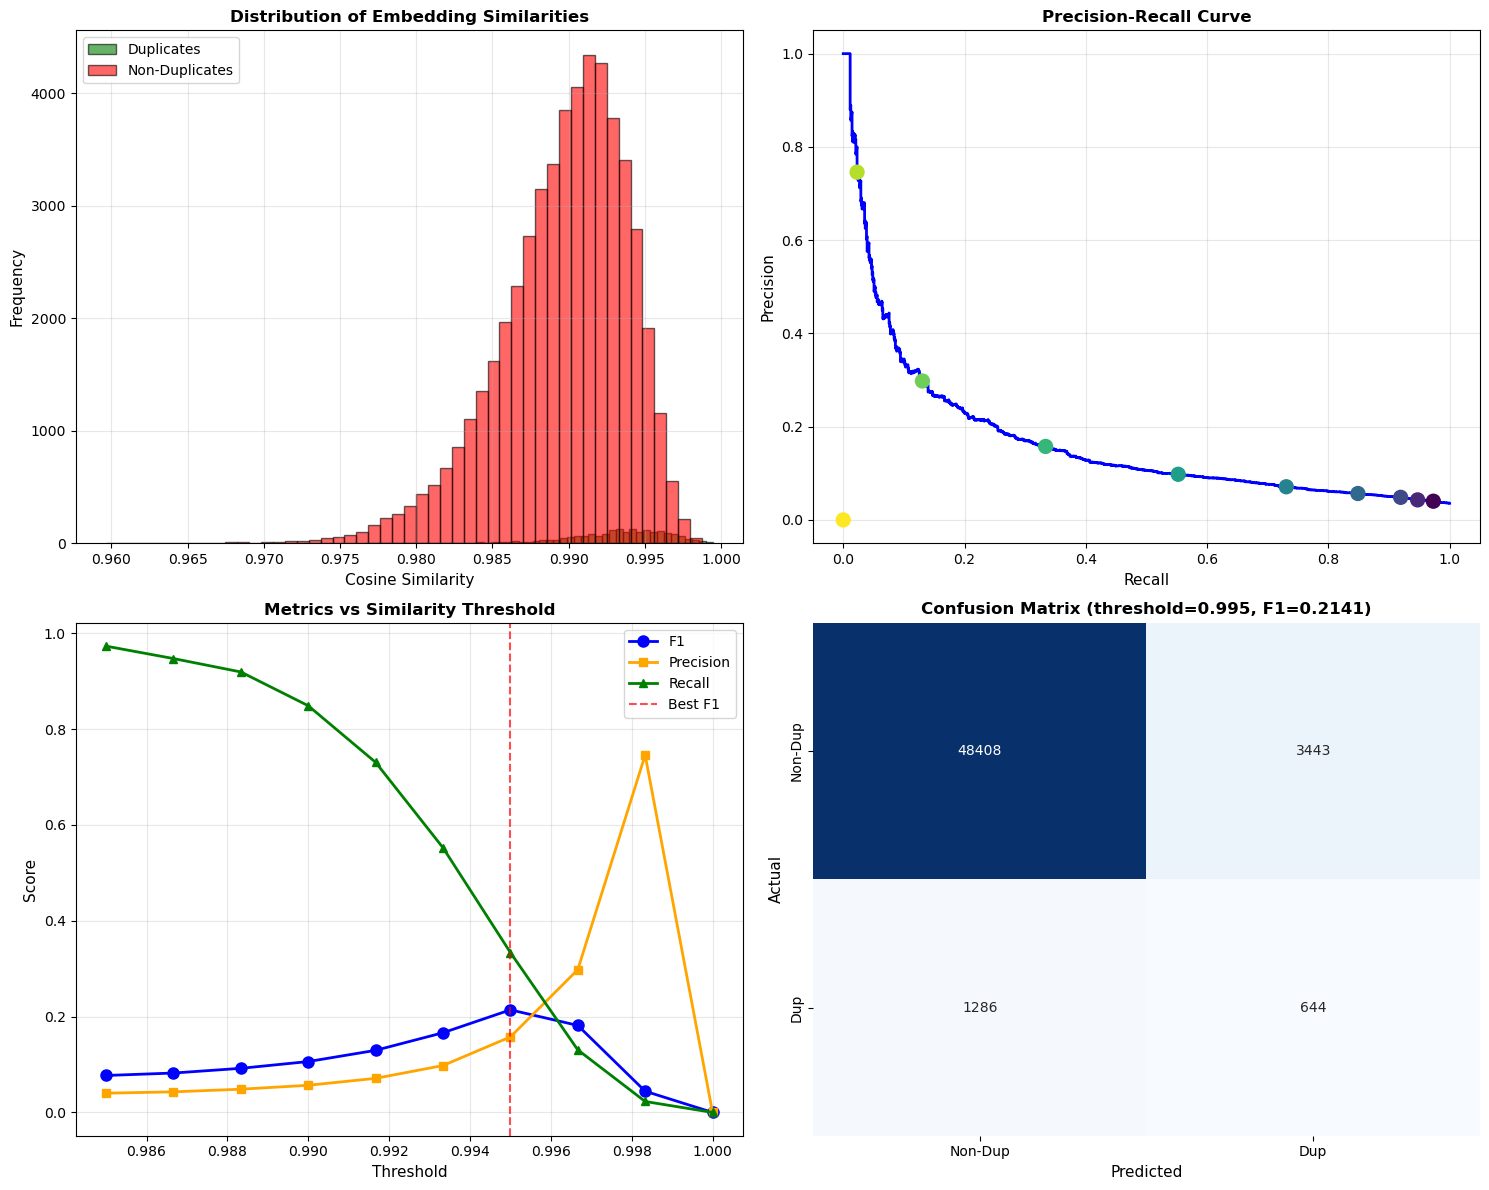


THRESHOLD EVALUATION RESULTS:
 Threshold  Precision   Recall       F1  Accuracy   TP    FP   FN    TN
  0.985000   0.040121 0.973057 0.077065  0.163608 1878 44930   52  6921
  0.986667   0.042950 0.947150 0.082174  0.240717 1828 40733  102 11118
  0.988333   0.048429 0.919171 0.092010  0.348971 1774 34857  156 16994
  0.990000   0.056606 0.848705 0.106133  0.486975 1638 27299  292 24552
  0.991667   0.071083 0.730570 0.129560  0.647719 1410 18426  520 33425
  0.993333   0.097852 0.552332 0.166251  0.801194 1066  9828  864 42023
  0.995000   0.157573 0.333679 0.214060  0.912069  644  3443 1286 48408
  0.996667   0.297872 0.130570 0.181556  0.957755  252   594 1678 51257
  0.998333   0.745763 0.022798 0.044243  0.964653   44    15 1886 51836
  1.000000   0.000000 0.000000 0.000000  0.964114    0     0 1930 51851
Evaluating embed_dim=8, output_dim=32
Model Configuration:
  vocab_size=38, embed_dim=8
  num_filters=128, kernel_sizes=(3, 4, 5)
  dropout=0.3, output_dim=32

1. Generating emb

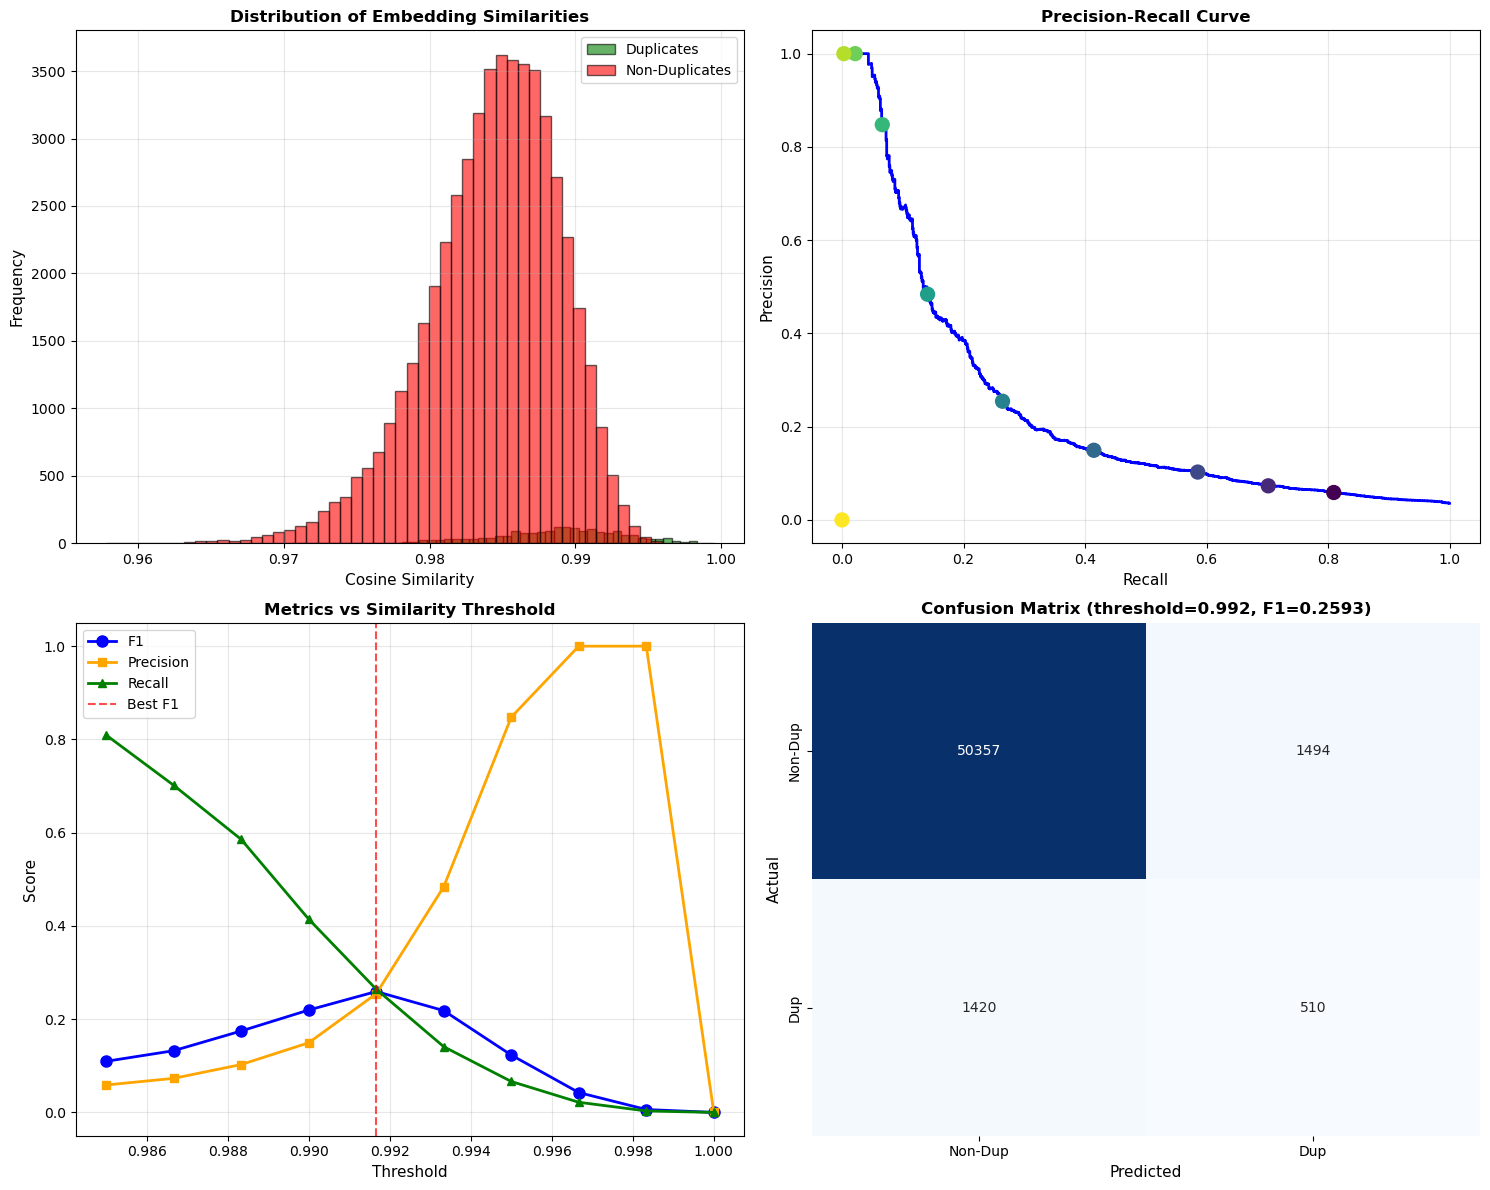


THRESHOLD EVALUATION RESULTS:
 Threshold  Precision   Recall       F1  Accuracy   TP    FP   FN    TN
  0.985000   0.058770 0.809326 0.109583  0.528012 1562 25016  368 26835
  0.986667   0.073067 0.701554 0.132349  0.669902 1354 17177  576 34674
  0.988333   0.102615 0.585492 0.174625  0.801380 1130  9882  800 41969
  0.990000   0.149337 0.414508 0.219569  0.894256  800  4557 1130 47294
  0.991667   0.254491 0.264249 0.259278  0.945817  510  1494 1420 50357
  0.993333   0.483986 0.140933 0.218299  0.963779  272   290 1658 51561
  0.995000   0.847682 0.066321 0.123018  0.966066  128    23 1802 51828
  0.996667   1.000000 0.021762 0.042596  0.964895   42     0 1888 51851
  0.998333   1.000000 0.003109 0.006198  0.964225    6     0 1924 51851
  1.000000   0.000000 0.000000 0.000000  0.964114    0     0 1930 51851
Evaluating embed_dim=8, output_dim=64
Model Configuration:
  vocab_size=38, embed_dim=8
  num_filters=128, kernel_sizes=(3, 4, 5)
  dropout=0.3, output_dim=64

1. Generating emb

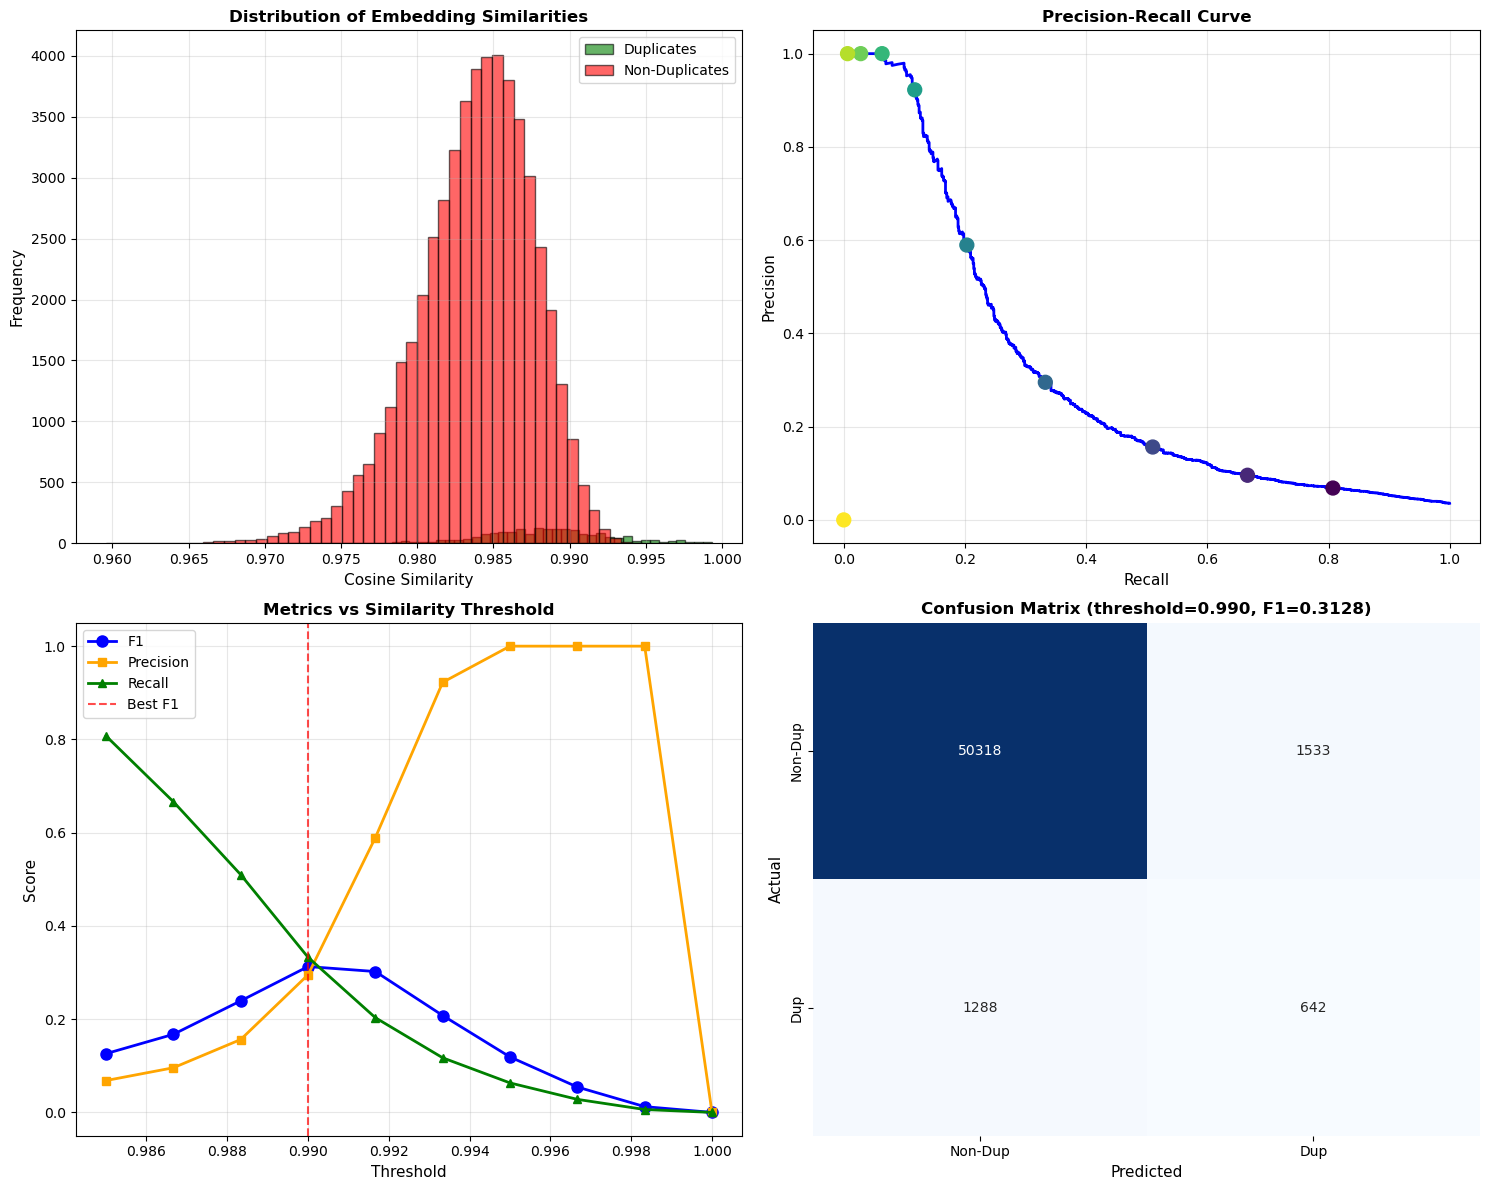


THRESHOLD EVALUATION RESULTS:
 Threshold  Precision   Recall       F1  Accuracy   TP    FP   FN    TN
  0.985000   0.068360 0.807254 0.126047  0.598278 1558 21233  372 30618
  0.986667   0.095784 0.666321 0.167492  0.762295 1286 12140  644 39711
  0.988333   0.156339 0.509845 0.239300  0.883676  984  5310  946 46541
  0.990000   0.295172 0.332642 0.312789  0.947547  642  1533 1288 50318
  0.991667   0.589474 0.203109 0.302119  0.966326  392   273 1538 51578
  0.993333   0.922449 0.117098 0.207816  0.967963  226    19 1704 51832
  0.995000   1.000000 0.063212 0.118908  0.966382  122     0 1808 51851
  0.996667   1.000000 0.027979 0.054435  0.965118   54     0 1876 51851
  0.998333   1.000000 0.006218 0.012358  0.964337   12     0 1918 51851
  1.000000   0.000000 0.000000 0.000000  0.964114    0     0 1930 51851
Evaluating embed_dim=8, output_dim=128
Model Configuration:
  vocab_size=38, embed_dim=8
  num_filters=128, kernel_sizes=(3, 4, 5)
  dropout=0.3, output_dim=128

1. Generating e

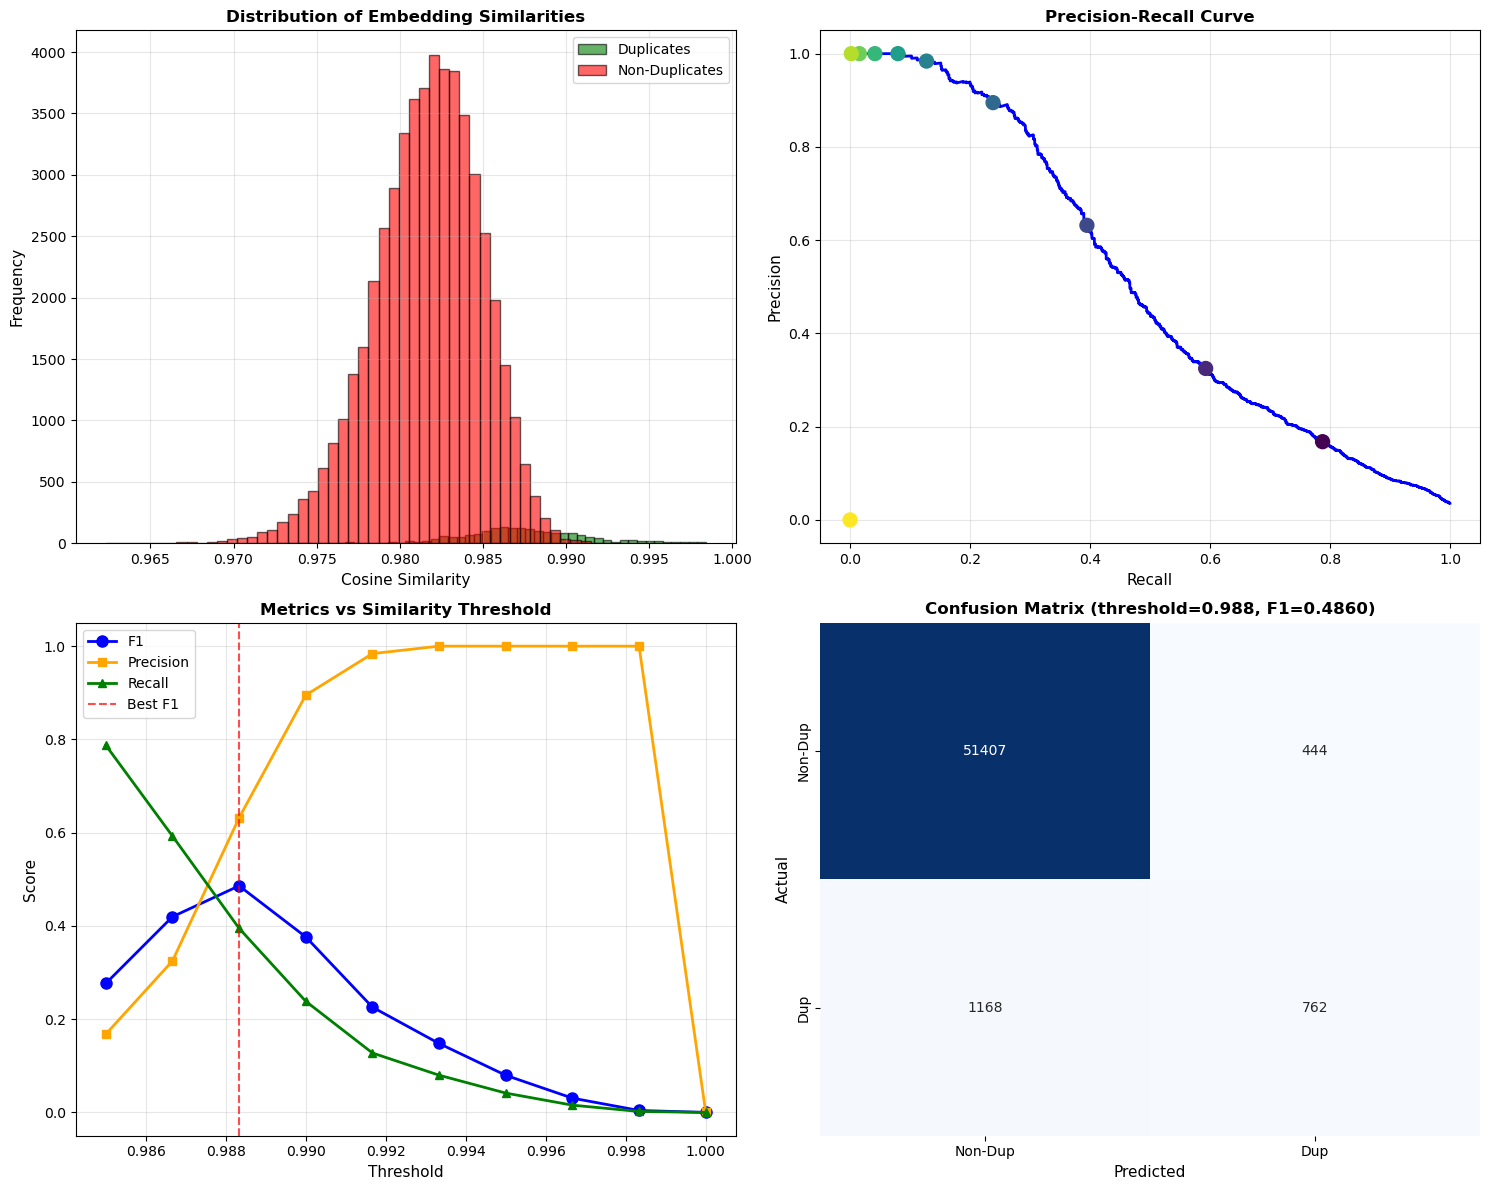


THRESHOLD EVALUATION RESULTS:
 Threshold  Precision   Recall       F1  Accuracy   TP   FP   FN    TN
  0.985000   0.167733 0.787565 0.276565  0.852141 1520 7542  410 44309
  0.986667   0.324815 0.592746 0.419663  0.941169 1144 2378  786 49473
  0.988333   0.631841 0.394819 0.485969  0.970027  762  444 1168 51407
  0.990000   0.894942 0.238342 0.376432  0.971663  460   54 1470 51797
  0.991667   0.984000 0.127461 0.225688  0.968613  246    4 1684 51847
  0.993333   1.000000 0.079793 0.147793  0.966977  154    0 1776 51851
  0.995000   1.000000 0.041451 0.079602  0.965601   80    0 1850 51851
  0.996667   1.000000 0.015544 0.030612  0.964672   30    0 1900 51851
  0.998333   1.000000 0.002073 0.004137  0.964188    4    0 1926 51851
  1.000000   0.000000 0.000000 0.000000  0.964114    0    0 1930 51851
Evaluating embed_dim=16, output_dim=16
Model Configuration:
  vocab_size=38, embed_dim=16
  num_filters=128, kernel_sizes=(3, 4, 5)
  dropout=0.3, output_dim=16

1. Generating embeddings..

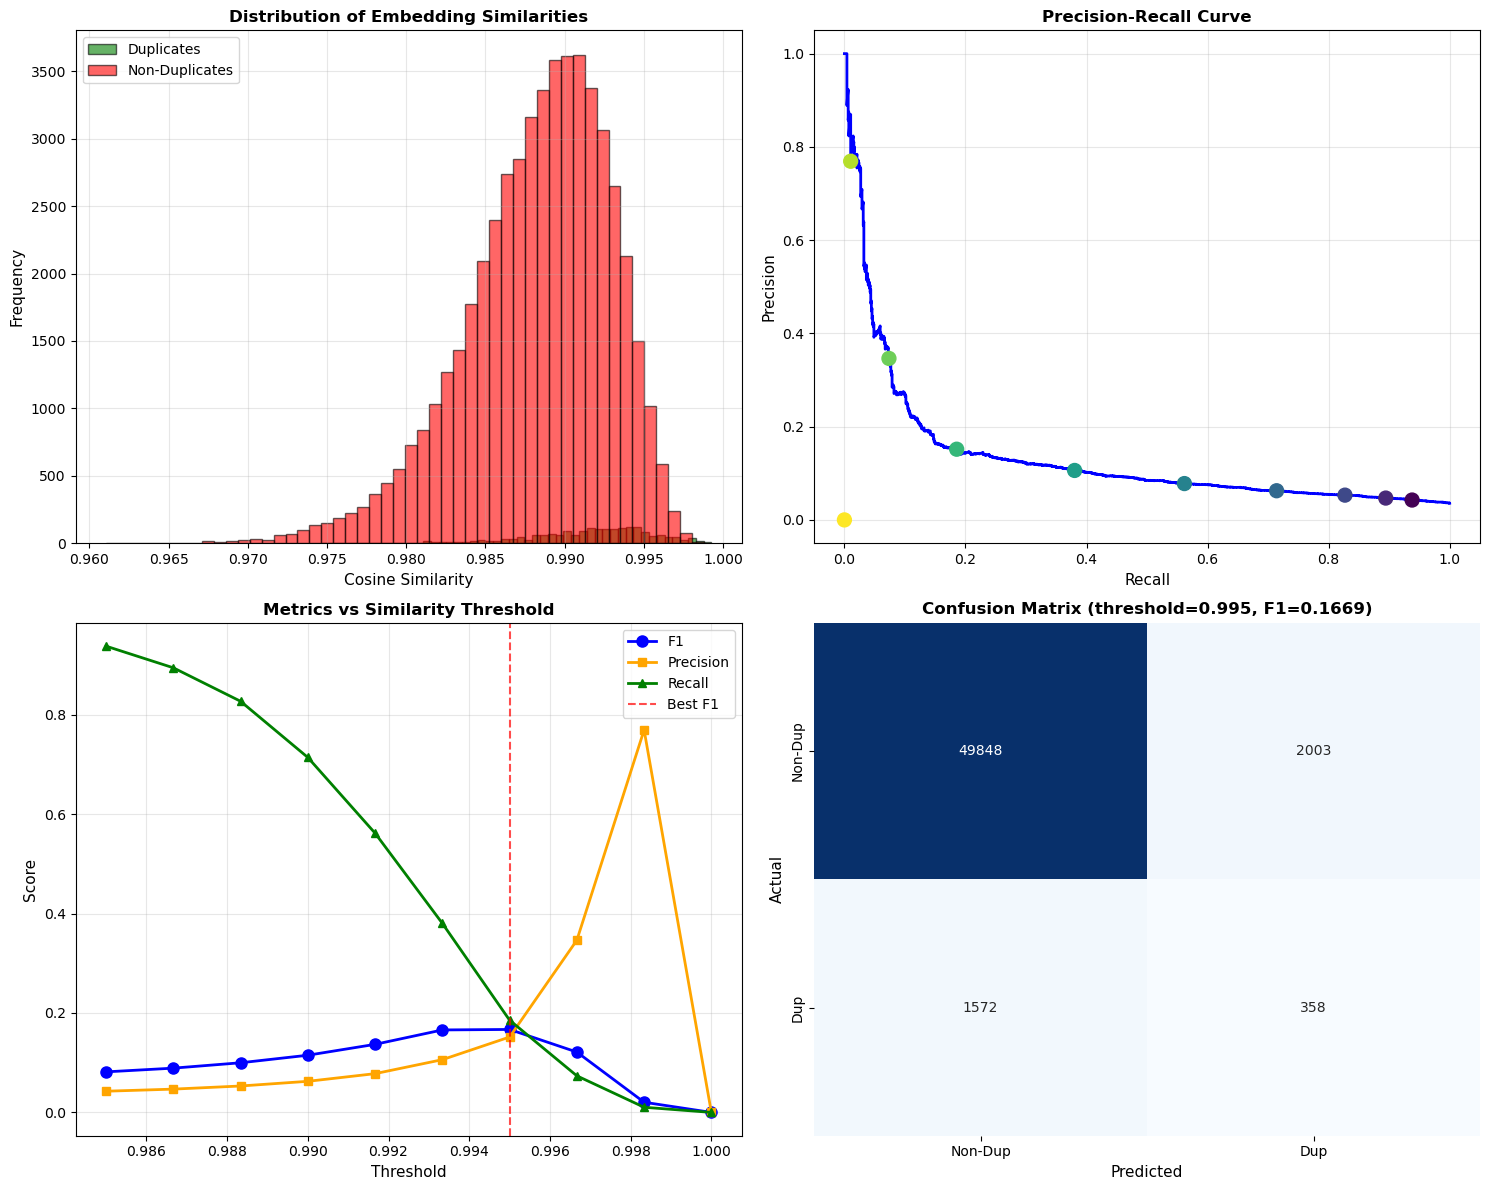


THRESHOLD EVALUATION RESULTS:
 Threshold  Precision   Recall       F1  Accuracy   TP    FP   FN    TN
  0.985000   0.042628 0.937824 0.081550  0.241926 1810 40650  120 11201
  0.986667   0.046846 0.894301 0.089029  0.343225 1726 35118  204 16733
  0.988333   0.053129 0.826943 0.099844  0.464904 1596 28444  334 23407
  0.990000   0.062540 0.713990 0.115006  0.605660 1378 20656  552 31195
  0.991667   0.077952 0.561658 0.136903  0.745858 1084 12822  846 39029
  0.993333   0.106069 0.380311 0.165876  0.862740  734  6186 1196 45665
  0.995000   0.151631 0.185492 0.166861  0.933527  358  2003 1572 49848
  0.996667   0.346341 0.073575 0.121368  0.961771  142   268 1788 51583
  0.998333   0.769231 0.010363 0.020450  0.964374   20     6 1910 51845
  1.000000   0.000000 0.000000 0.000000  0.964114    0     0 1930 51851
Evaluating embed_dim=16, output_dim=32
Model Configuration:
  vocab_size=38, embed_dim=16
  num_filters=128, kernel_sizes=(3, 4, 5)
  dropout=0.3, output_dim=32

1. Generating e

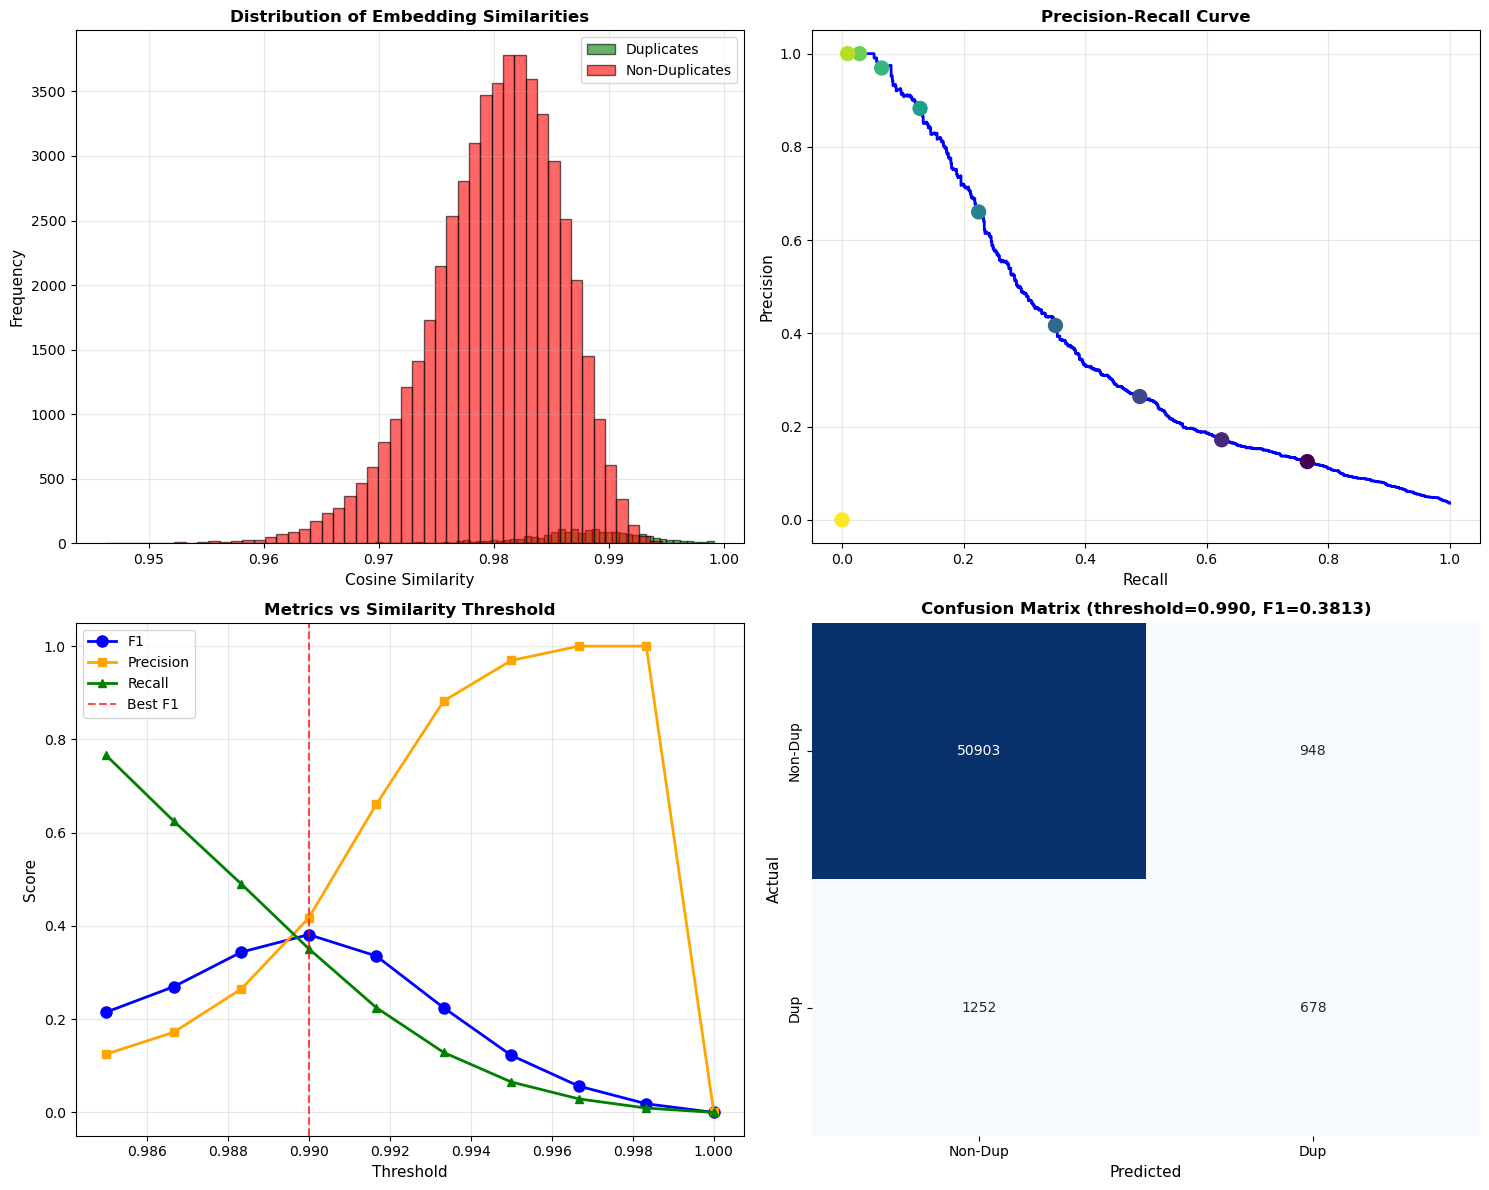


THRESHOLD EVALUATION RESULTS:
 Threshold  Precision   Recall       F1  Accuracy   TP    FP   FN    TN
  0.985000   0.125063 0.765803 0.215013  0.799334 1478 10340  452 41511
  0.986667   0.171844 0.624870 0.269557  0.878470 1206  5812  724 46039
  0.988333   0.264615 0.490155 0.343688  0.932820  946  2629  984 49222
  0.990000   0.416974 0.351295 0.381327  0.959093  678   948 1252 50903
  0.991667   0.660578 0.224870 0.335524  0.968037  434   223 1496 51628
  0.993333   0.882562 0.128497 0.224333  0.968111  248    33 1682 51818
  0.995000   0.969231 0.065285 0.122330  0.966382  126     4 1804 51847
  0.996667   1.000000 0.029016 0.056395  0.965155   56     0 1874 51851
  0.998333   1.000000 0.009326 0.018480  0.964448   18     0 1912 51851
  1.000000   0.000000 0.000000 0.000000  0.964114    0     0 1930 51851
Evaluating embed_dim=16, output_dim=64
Model Configuration:
  vocab_size=38, embed_dim=16
  num_filters=128, kernel_sizes=(3, 4, 5)
  dropout=0.3, output_dim=64

1. Generating e

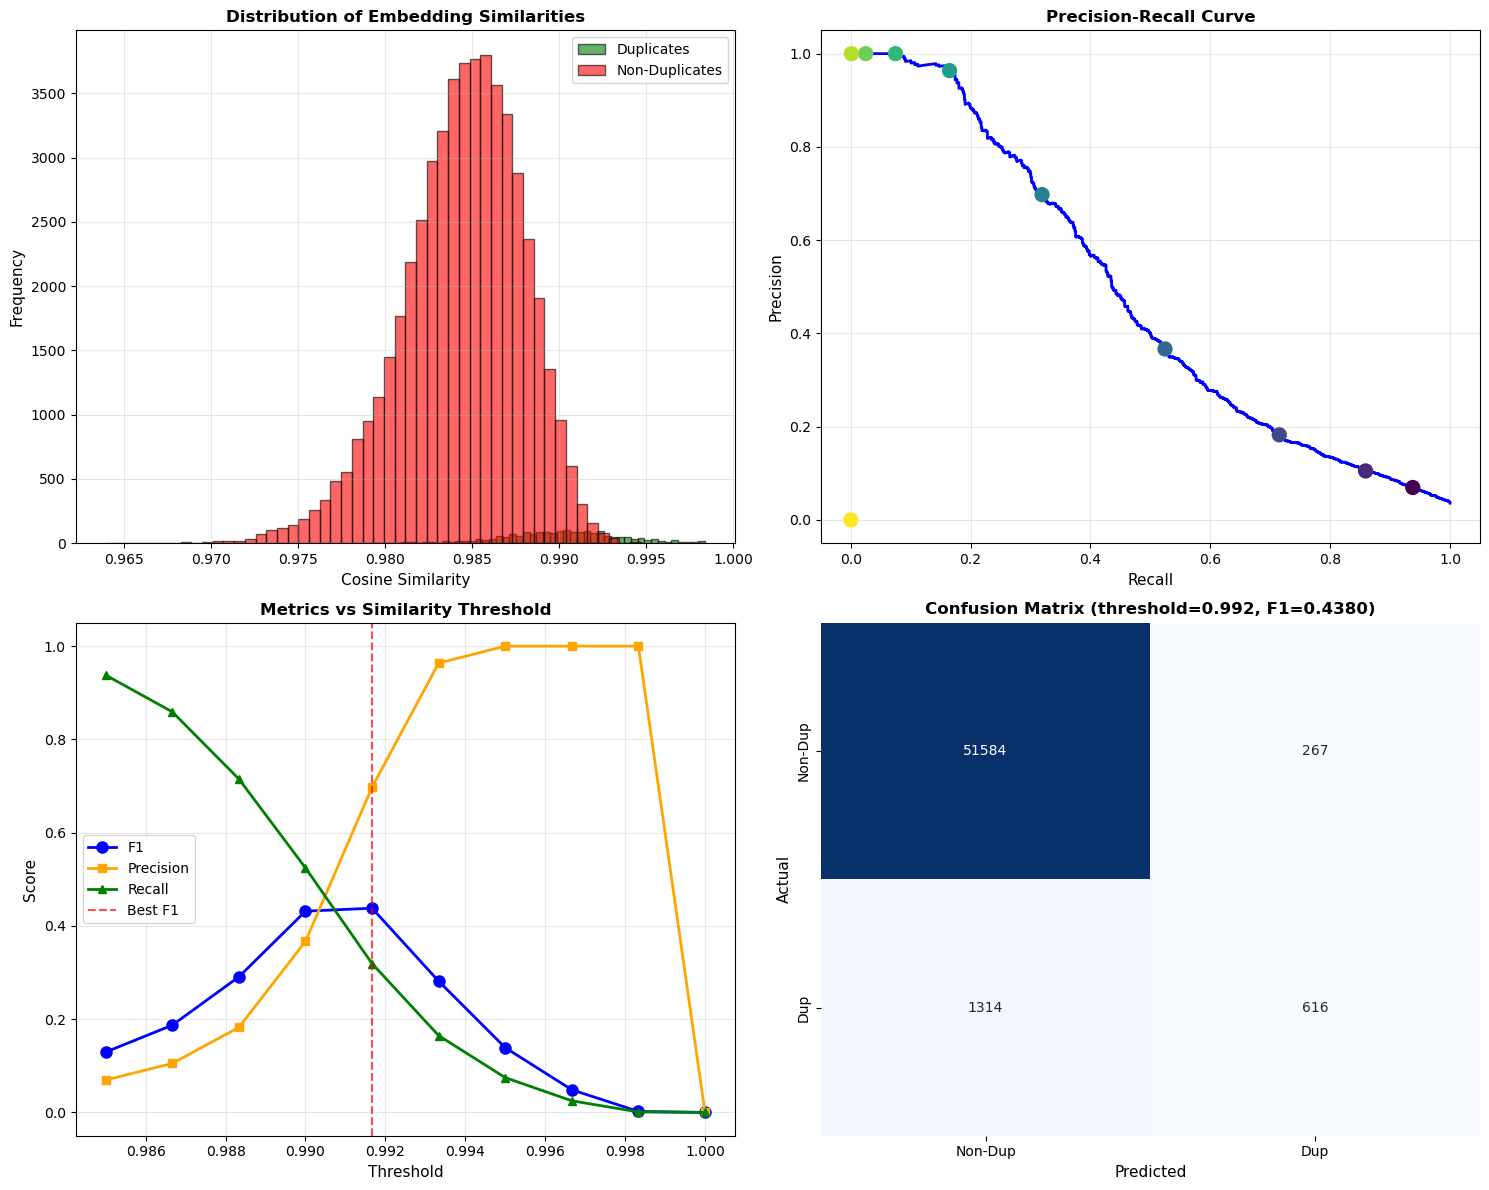


THRESHOLD EVALUATION RESULTS:
 Threshold  Precision   Recall       F1  Accuracy   TP    FP   FN    TN
  0.985000   0.069540 0.937824 0.129480  0.547461 1810 24218  120 27633
  0.986667   0.105010 0.859067 0.187144  0.732192 1658 14131  272 37720
  0.988333   0.182491 0.715026 0.290771  0.874826 1380  6182  550 45669
  0.990000   0.366667 0.524352 0.431557  0.950429 1012  1748  918 50103
  0.991667   0.697622 0.319171 0.437967  0.970603  616   267 1314 51584
  0.993333   0.963636 0.164767 0.281416  0.969803  318    12 1612 51839
  0.995000   1.000000 0.074611 0.138862  0.966791  144     0 1786 51851
  0.996667   1.000000 0.024870 0.048534  0.965006   48     0 1882 51851
  0.998333   1.000000 0.001036 0.002070  0.964151    2     0 1928 51851
  1.000000   0.000000 0.000000 0.000000  0.964114    0     0 1930 51851
Evaluating embed_dim=16, output_dim=128
Model Configuration:
  vocab_size=38, embed_dim=16
  num_filters=128, kernel_sizes=(3, 4, 5)
  dropout=0.3, output_dim=128

1. Generating

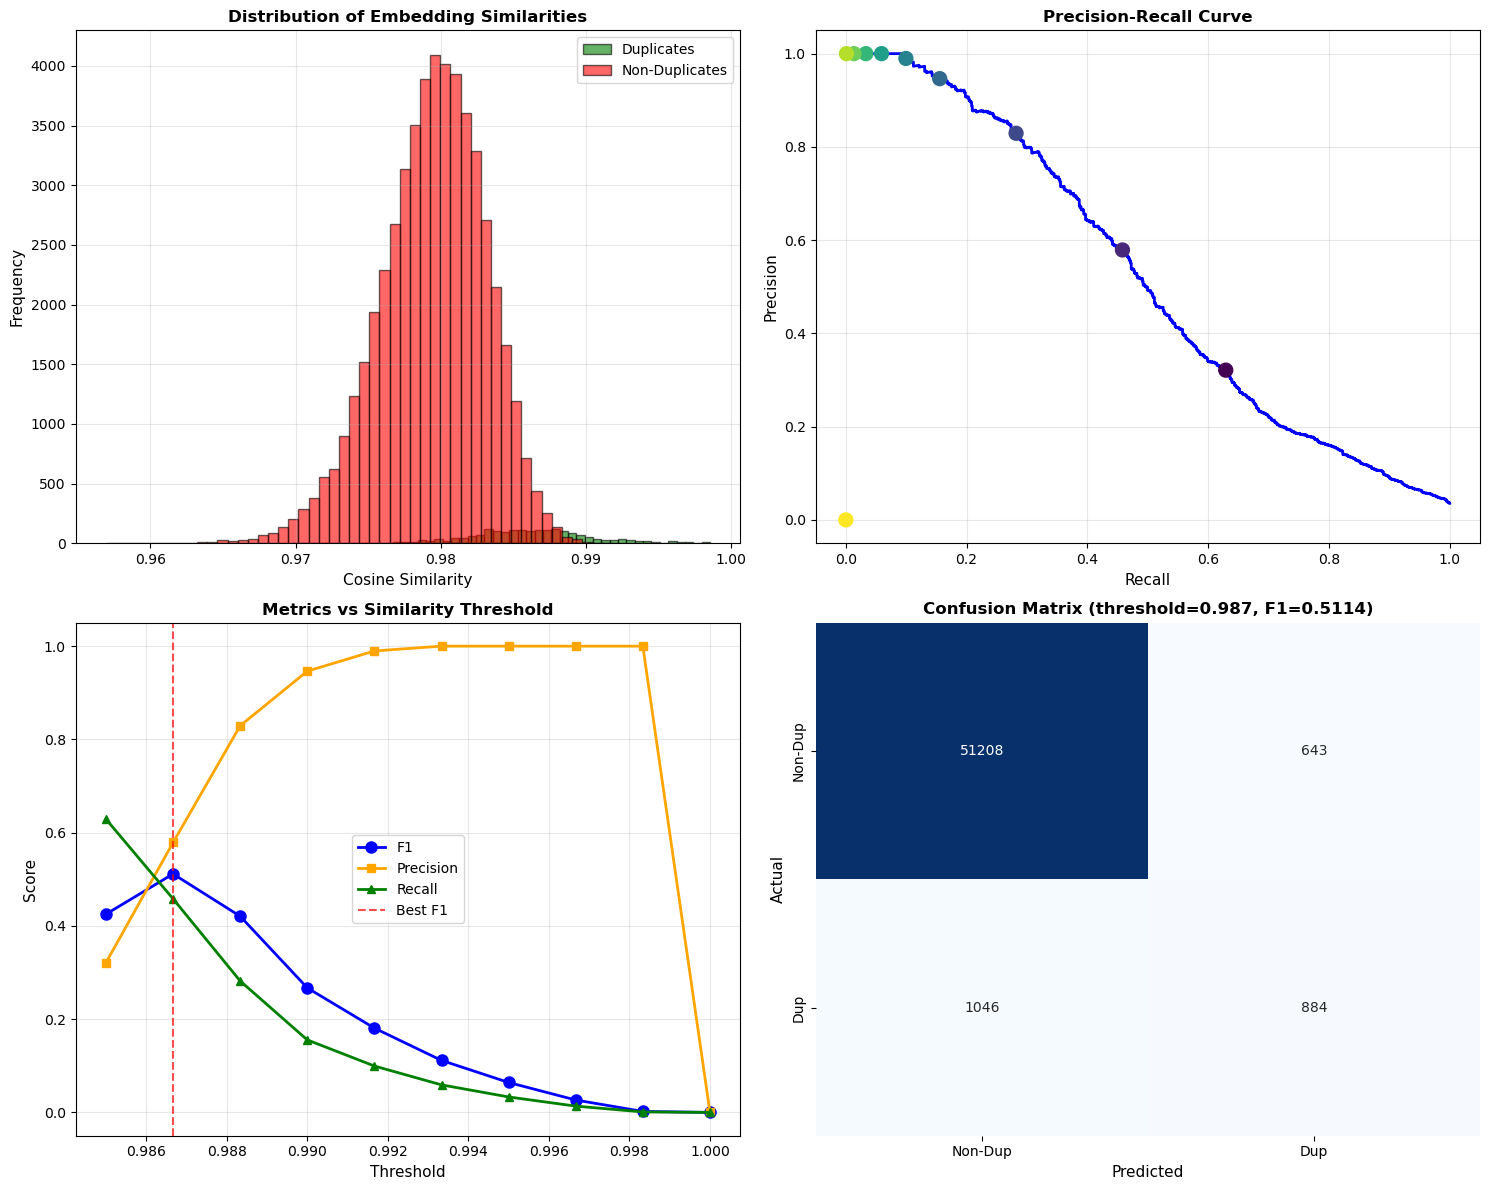


THRESHOLD EVALUATION RESULTS:
 Threshold  Precision   Recall       F1  Accuracy   TP   FP   FN    TN
  0.985000   0.321164 0.629016 0.425219  0.938975 1214 2566  716 49285
  0.986667   0.578913 0.458031 0.511426  0.968595  884  643 1046 51208
  0.988333   0.829268 0.281865 0.420727  0.972146  544  112 1386 51739
  0.990000   0.946372 0.155440 0.267023  0.969376  300   17 1630 51834
  0.991667   0.989691 0.099482 0.180791  0.967647  192    2 1738 51849
  0.993333   1.000000 0.059067 0.111546  0.966233  114    0 1816 51851
  0.995000   1.000000 0.033161 0.064193  0.965304   64    0 1866 51851
  0.996667   1.000000 0.013472 0.026585  0.964597   26    0 1904 51851
  0.998333   1.000000 0.001036 0.002070  0.964151    2    0 1928 51851
  1.000000   0.000000 0.000000 0.000000  0.964114    0    0 1930 51851
Evaluating embed_dim=32, output_dim=16
Model Configuration:
  vocab_size=38, embed_dim=32
  num_filters=128, kernel_sizes=(3, 4, 5)
  dropout=0.3, output_dim=16

1. Generating embeddings..

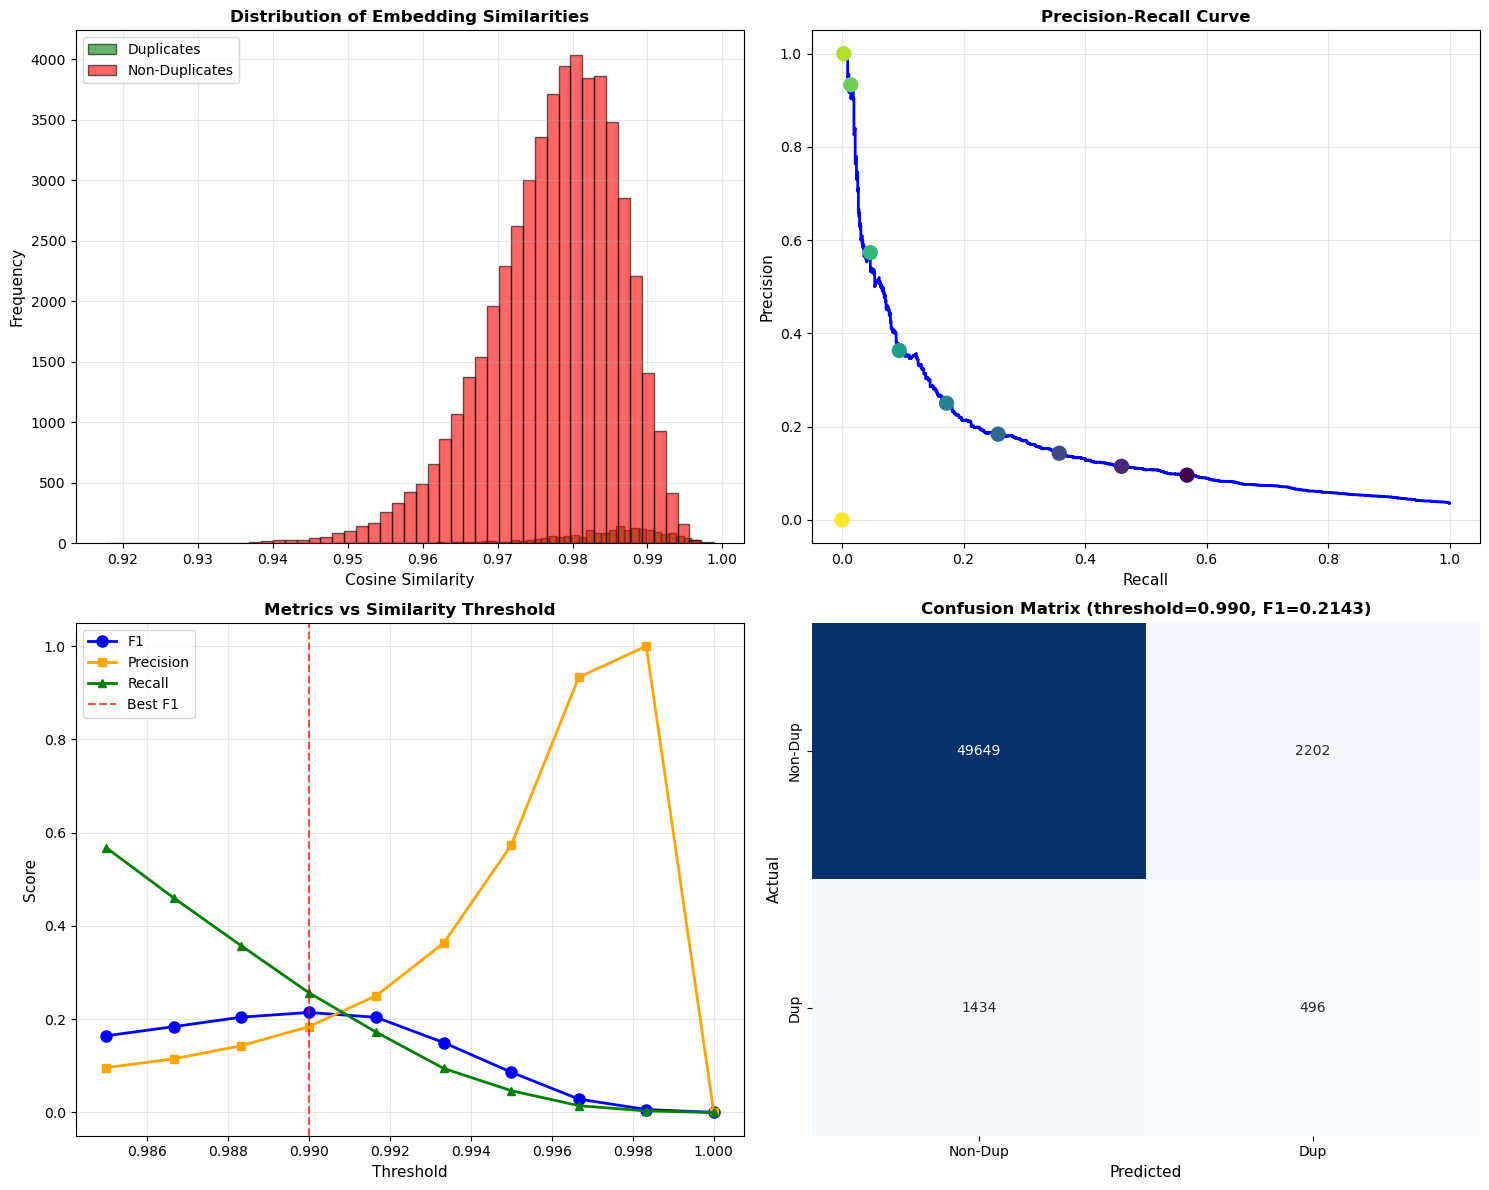


THRESHOLD EVALUATION RESULTS:
 Threshold  Precision   Recall       F1  Accuracy   TP    FP   FN    TN
  0.985000   0.096056 0.567876 0.164318  0.792715 1096 10314  834 41537
  0.986667   0.114937 0.460104 0.183927  0.853480  888  6838 1042 45013
  0.988333   0.142976 0.357513 0.204263  0.900039  690  4136 1240 47715
  0.990000   0.183840 0.256995 0.214347  0.932392  496  2202 1434 49649
  0.991667   0.250377 0.172021 0.203931  0.951805  332   994 1598 50857
  0.993333   0.363273 0.094301 0.149733  0.961566  182   319 1748 51532
  0.995000   0.573248 0.046632 0.086248  0.964541   90    67 1840 51784
  0.996667   0.933333 0.014508 0.028571  0.964597   28     2 1902 51849
  0.998333   1.000000 0.003109 0.006198  0.964225    6     0 1924 51851
  1.000000   0.000000 0.000000 0.000000  0.964114    0     0 1930 51851
Evaluating embed_dim=32, output_dim=32
Model Configuration:
  vocab_size=38, embed_dim=32
  num_filters=128, kernel_sizes=(3, 4, 5)
  dropout=0.3, output_dim=32

1. Generating e

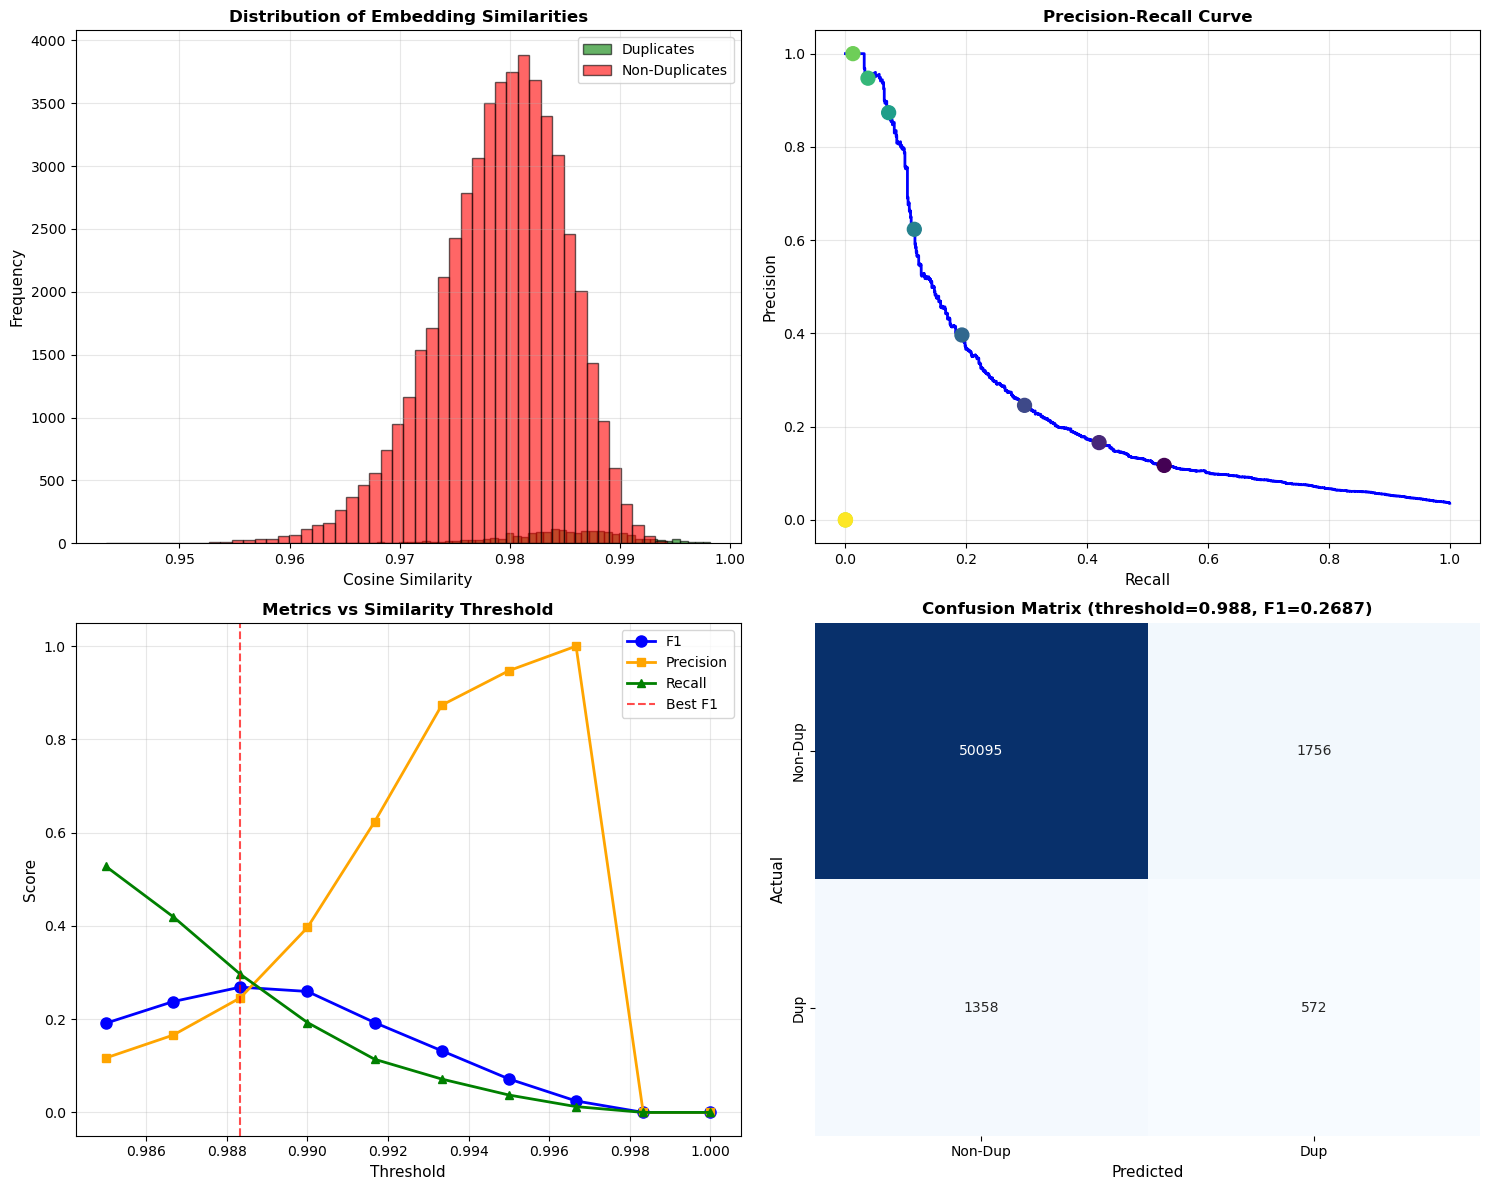


THRESHOLD EVALUATION RESULTS:
 Threshold  Precision   Recall       F1  Accuracy   TP   FP   FN    TN
  0.985000   0.116891 0.527461 0.191371  0.840036 1018 7691  912 44160
  0.986667   0.165814 0.419689 0.237711  0.903405  810 4075 1120 47776
  0.988333   0.245704 0.296373 0.268671  0.942099  572 1756 1358 50095
  0.990000   0.396588 0.192746 0.259414  0.960506  372  566 1558 51285
  0.991667   0.623229 0.113990 0.192729  0.965731  220  133 1710 51718
  0.993333   0.873418 0.071503 0.132184  0.966308  138   20 1792 51831
  0.995000   0.947368 0.037306 0.071785  0.965378   72    4 1858 51847
  0.996667   1.000000 0.012435 0.024565  0.964560   24    0 1906 51851
  0.998333   0.000000 0.000000 0.000000  0.964114    0    0 1930 51851
  1.000000   0.000000 0.000000 0.000000  0.964114    0    0 1930 51851
Evaluating embed_dim=32, output_dim=64
Model Configuration:
  vocab_size=38, embed_dim=32
  num_filters=128, kernel_sizes=(3, 4, 5)
  dropout=0.3, output_dim=64

1. Generating embeddings..

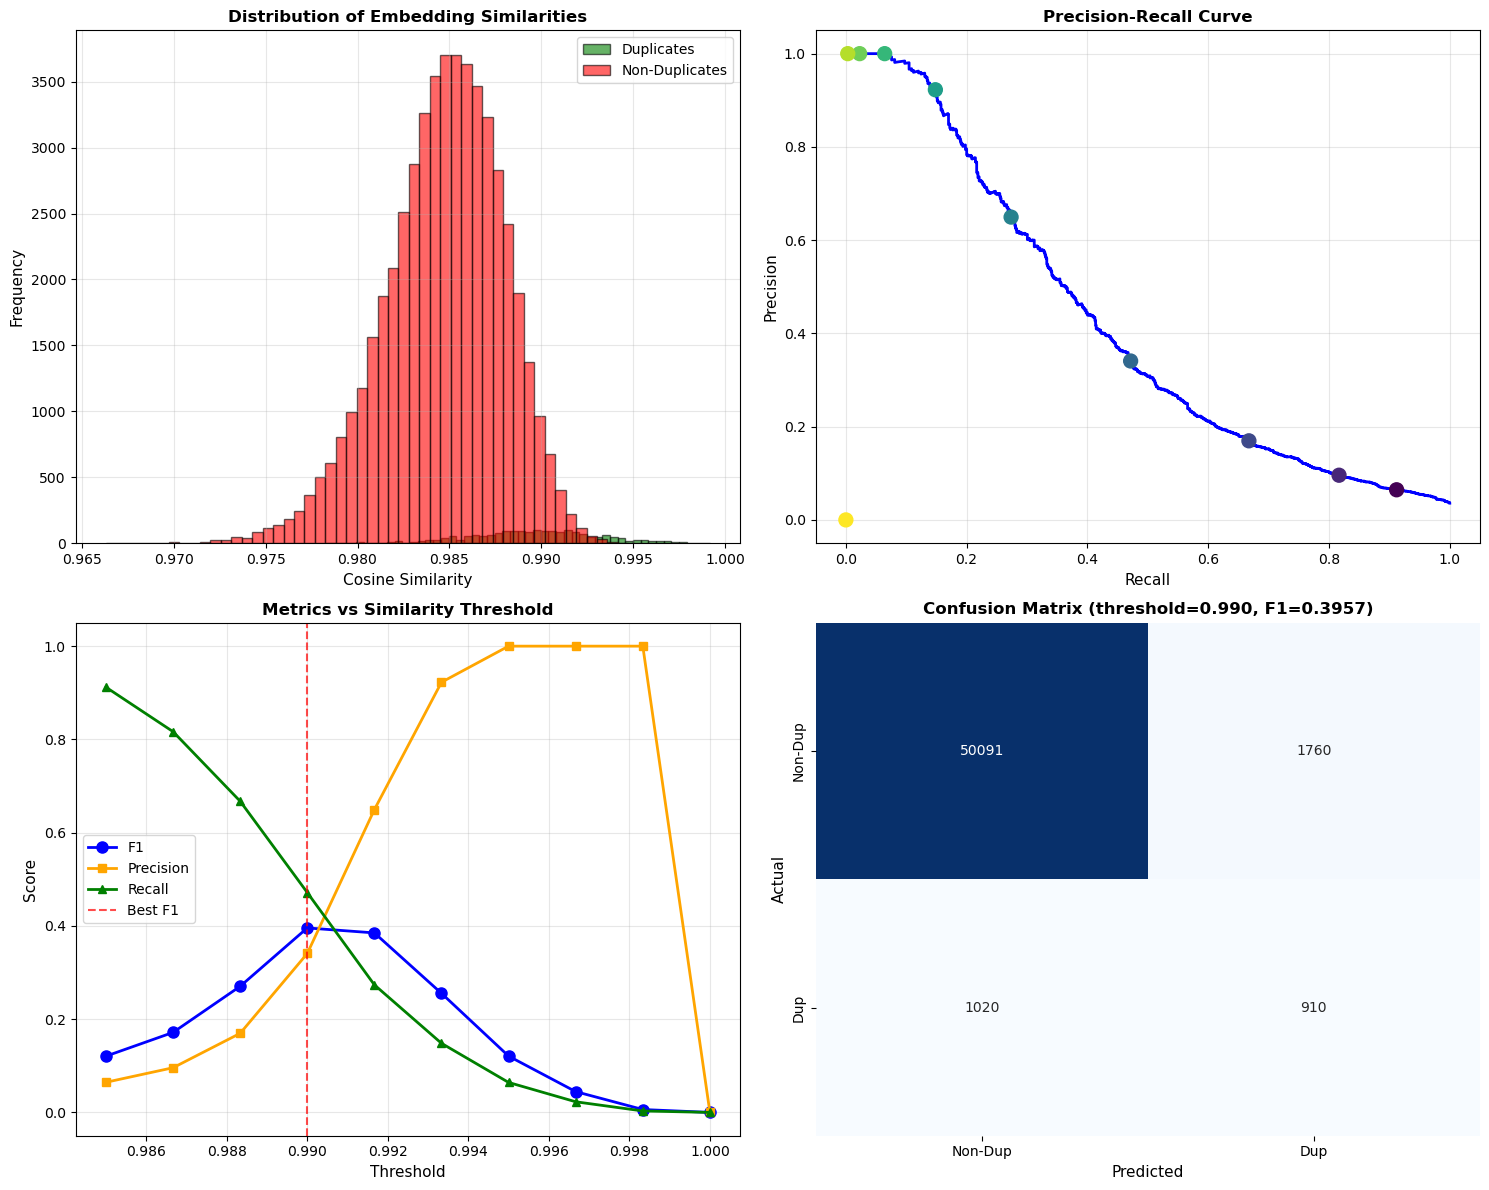


THRESHOLD EVALUATION RESULTS:
 Threshold  Precision   Recall       F1  Accuracy   TP    FP   FN    TN
  0.985000   0.064613 0.911917 0.120676  0.523084 1760 25479  170 26372
  0.986667   0.095846 0.816580 0.171556  0.716982 1576 14867  354 36984
  0.988333   0.169630 0.667358 0.270503  0.870828 1288  6305  642 45546
  0.990000   0.340824 0.471503 0.395652  0.948309  910  1760 1020 50091
  0.991667   0.649446 0.273575 0.384980  0.968632  528   285 1402 51566
  0.993333   0.922581 0.148187 0.255357  0.968985  286    24 1644 51827
  0.995000   1.000000 0.064249 0.120740  0.966419  124     0 1806 51851
  0.996667   1.000000 0.022798 0.044580  0.964932   44     0 1886 51851
  0.998333   1.000000 0.003109 0.006198  0.964225    6     0 1924 51851
  1.000000   0.000000 0.000000 0.000000  0.964114    0     0 1930 51851
Evaluating embed_dim=32, output_dim=128
Model Configuration:
  vocab_size=38, embed_dim=32
  num_filters=128, kernel_sizes=(3, 4, 5)
  dropout=0.3, output_dim=128

1. Generating

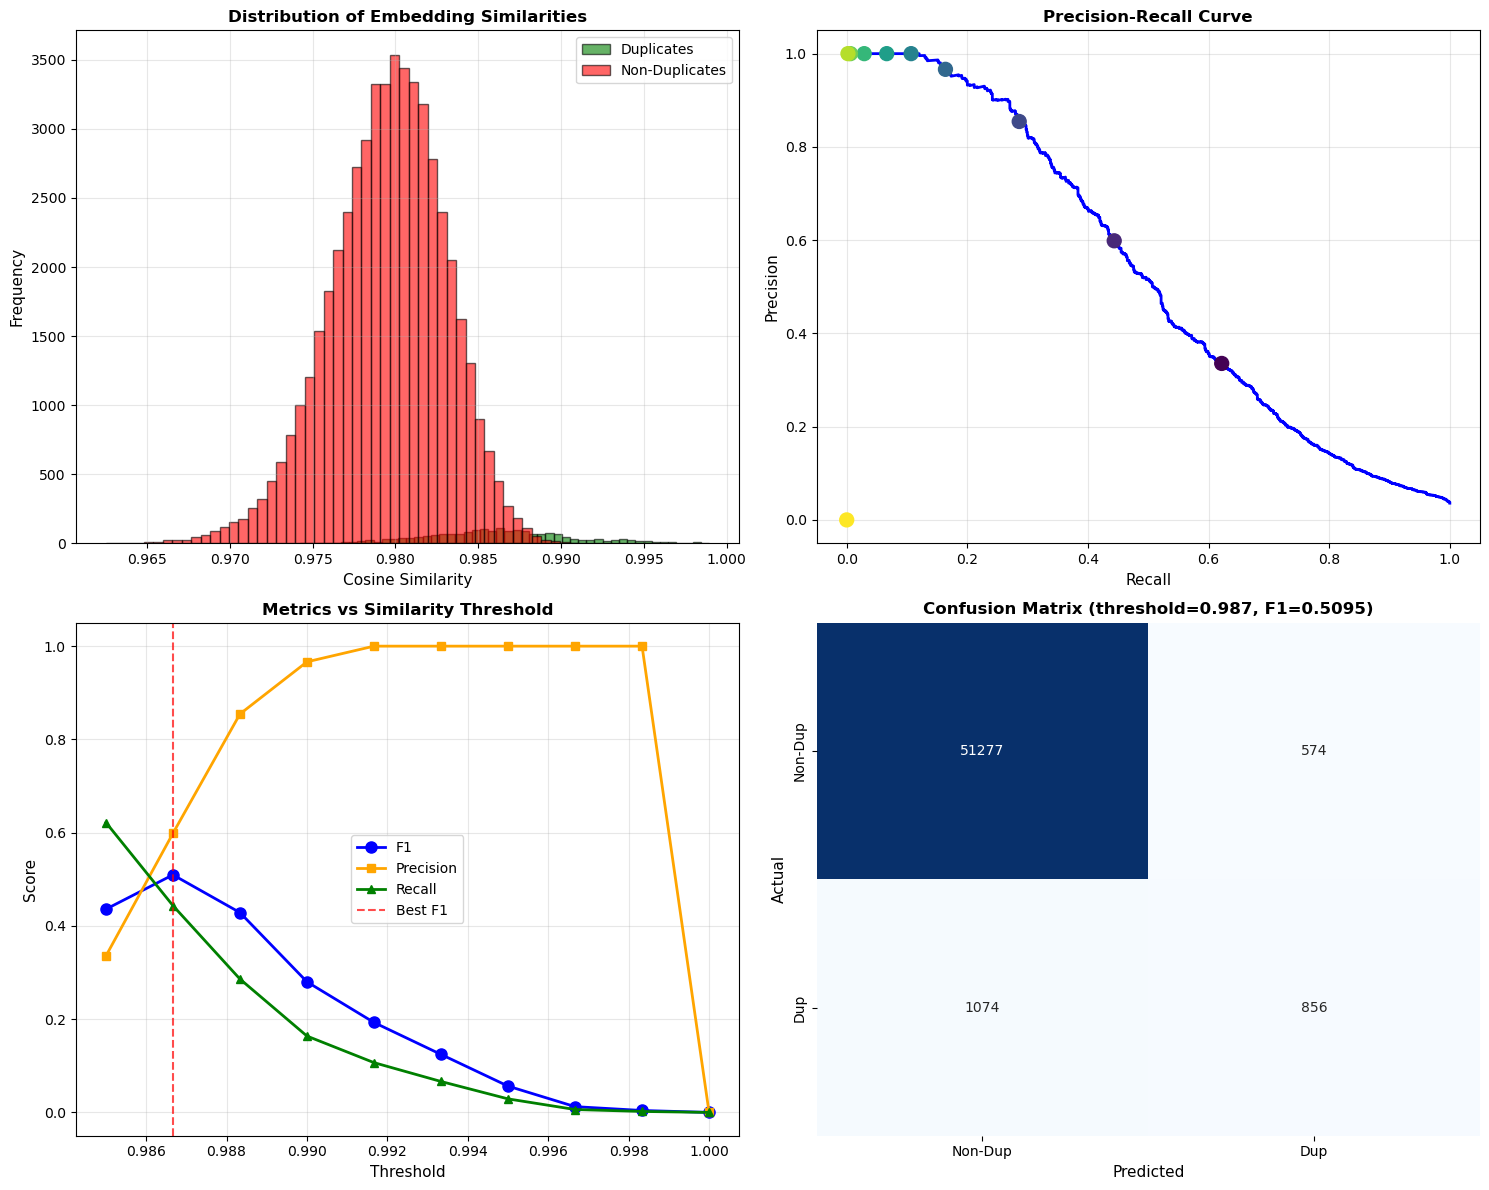


THRESHOLD EVALUATION RESULTS:
 Threshold  Precision   Recall       F1  Accuracy   TP   FP   FN    TN
  0.985000   0.335570 0.621762 0.435888  0.942247 1200 2376  730 49475
  0.986667   0.598601 0.443523 0.509524  0.969357  856  574 1074 51277
  0.988333   0.854489 0.286010 0.428571  0.972630  552   94 1378 51757
  0.990000   0.966361 0.163731 0.280018  0.969785  316   11 1614 51840
  0.991667   1.000000 0.106736 0.192884  0.967944  206    0 1724 51851
  0.993333   1.000000 0.066321 0.124393  0.966494  128    0 1802 51851
  0.995000   1.000000 0.029016 0.056395  0.965155   56    0 1874 51851
  0.996667   1.000000 0.006218 0.012358  0.964337   12    0 1918 51851
  0.998333   1.000000 0.002073 0.004137  0.964188    4    0 1926 51851
  1.000000   0.000000 0.000000 0.000000  0.964114    0    0 1930 51851
Evaluating embed_dim=64, output_dim=16
Model Configuration:
  vocab_size=38, embed_dim=64
  num_filters=128, kernel_sizes=(3, 4, 5)
  dropout=0.3, output_dim=16

1. Generating embeddings..

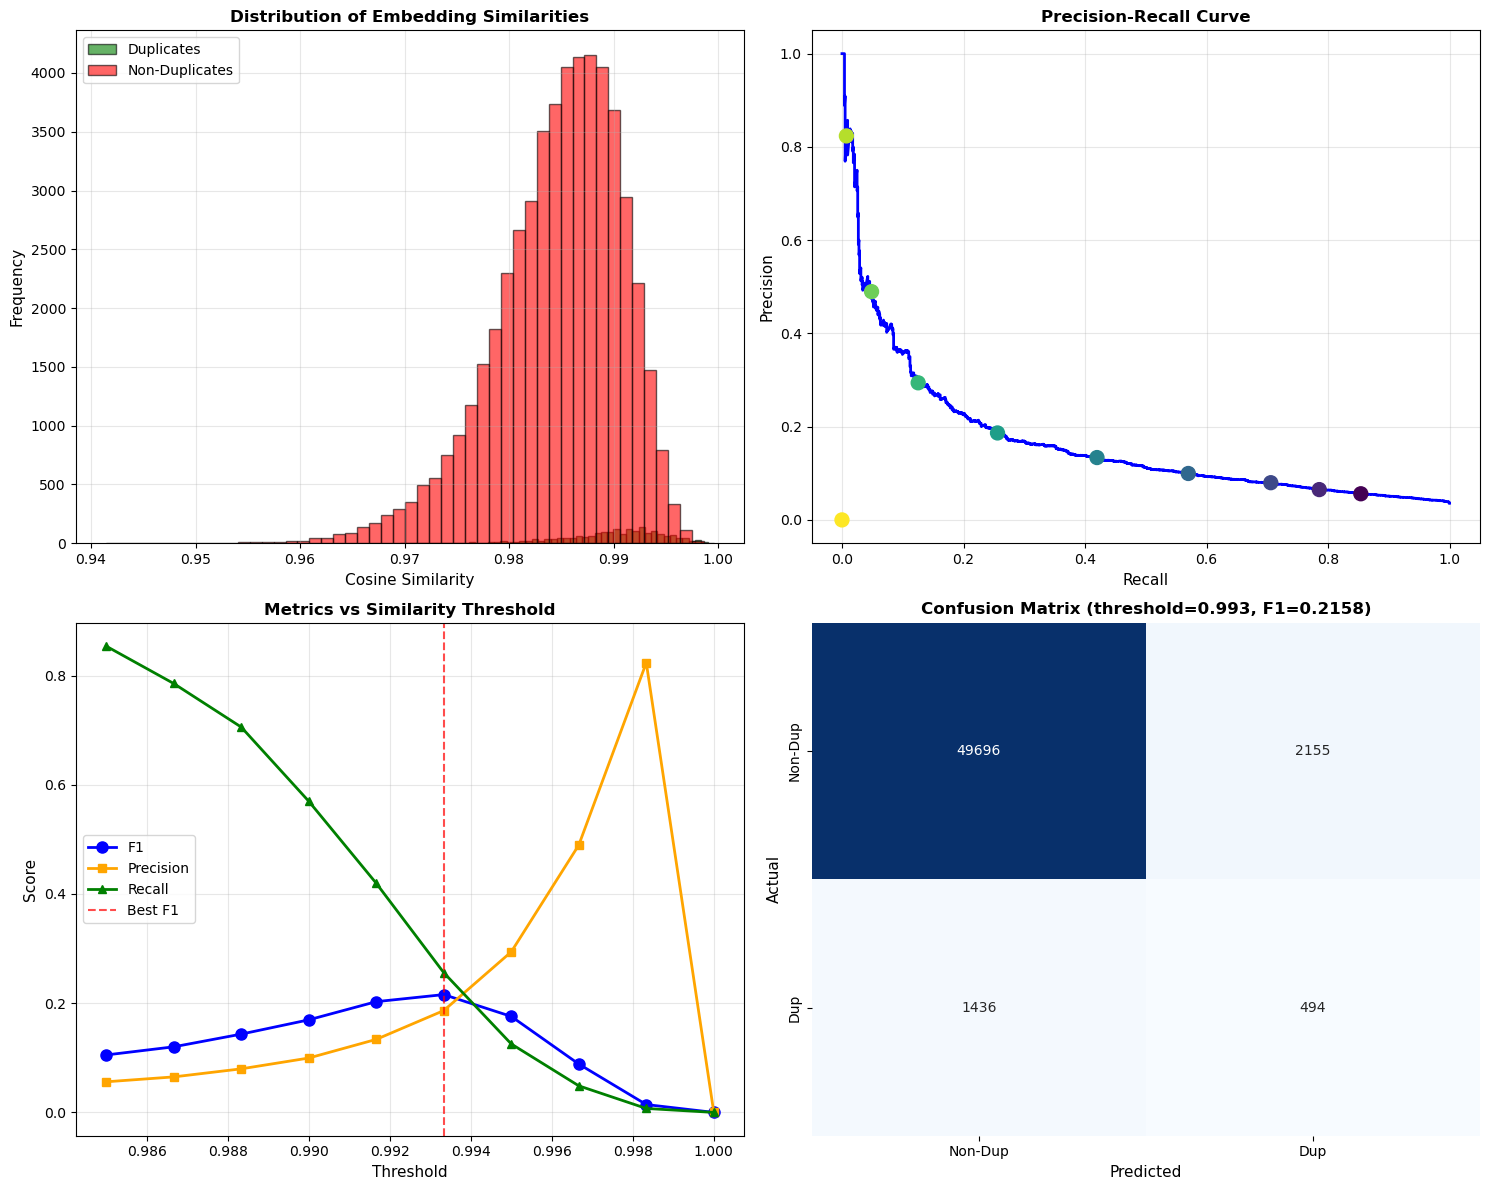


THRESHOLD EVALUATION RESULTS:
 Threshold  Precision   Recall       F1  Accuracy   TP    FP   FN    TN
  0.985000   0.056056 0.853886 0.105206  0.478756 1648 27751  282 24100
  0.986667   0.065028 0.785492 0.120113  0.587010 1516 21797  414 30054
  0.988333   0.079784 0.705699 0.143361  0.697347 1362 15709  568 36142
  0.990000   0.099566 0.569948 0.169518  0.799595 1100  9948  830 41903
  0.991667   0.133730 0.419689 0.202830  0.881612  810  5247 1120 46604
  0.993333   0.186485 0.255959 0.215768  0.933229  494  2155 1436 49696
  0.995000   0.294046 0.125389 0.175808  0.957810  242   581 1688 51270
  0.996667   0.489583 0.048705 0.088596  0.964039   94    98 1836 51753
  0.998333   0.823529 0.007254 0.014381  0.964318   14     3 1916 51848
  1.000000   0.000000 0.000000 0.000000  0.964114    0     0 1930 51851
Evaluating embed_dim=64, output_dim=32
Model Configuration:
  vocab_size=38, embed_dim=64
  num_filters=128, kernel_sizes=(3, 4, 5)
  dropout=0.3, output_dim=32

1. Generating e

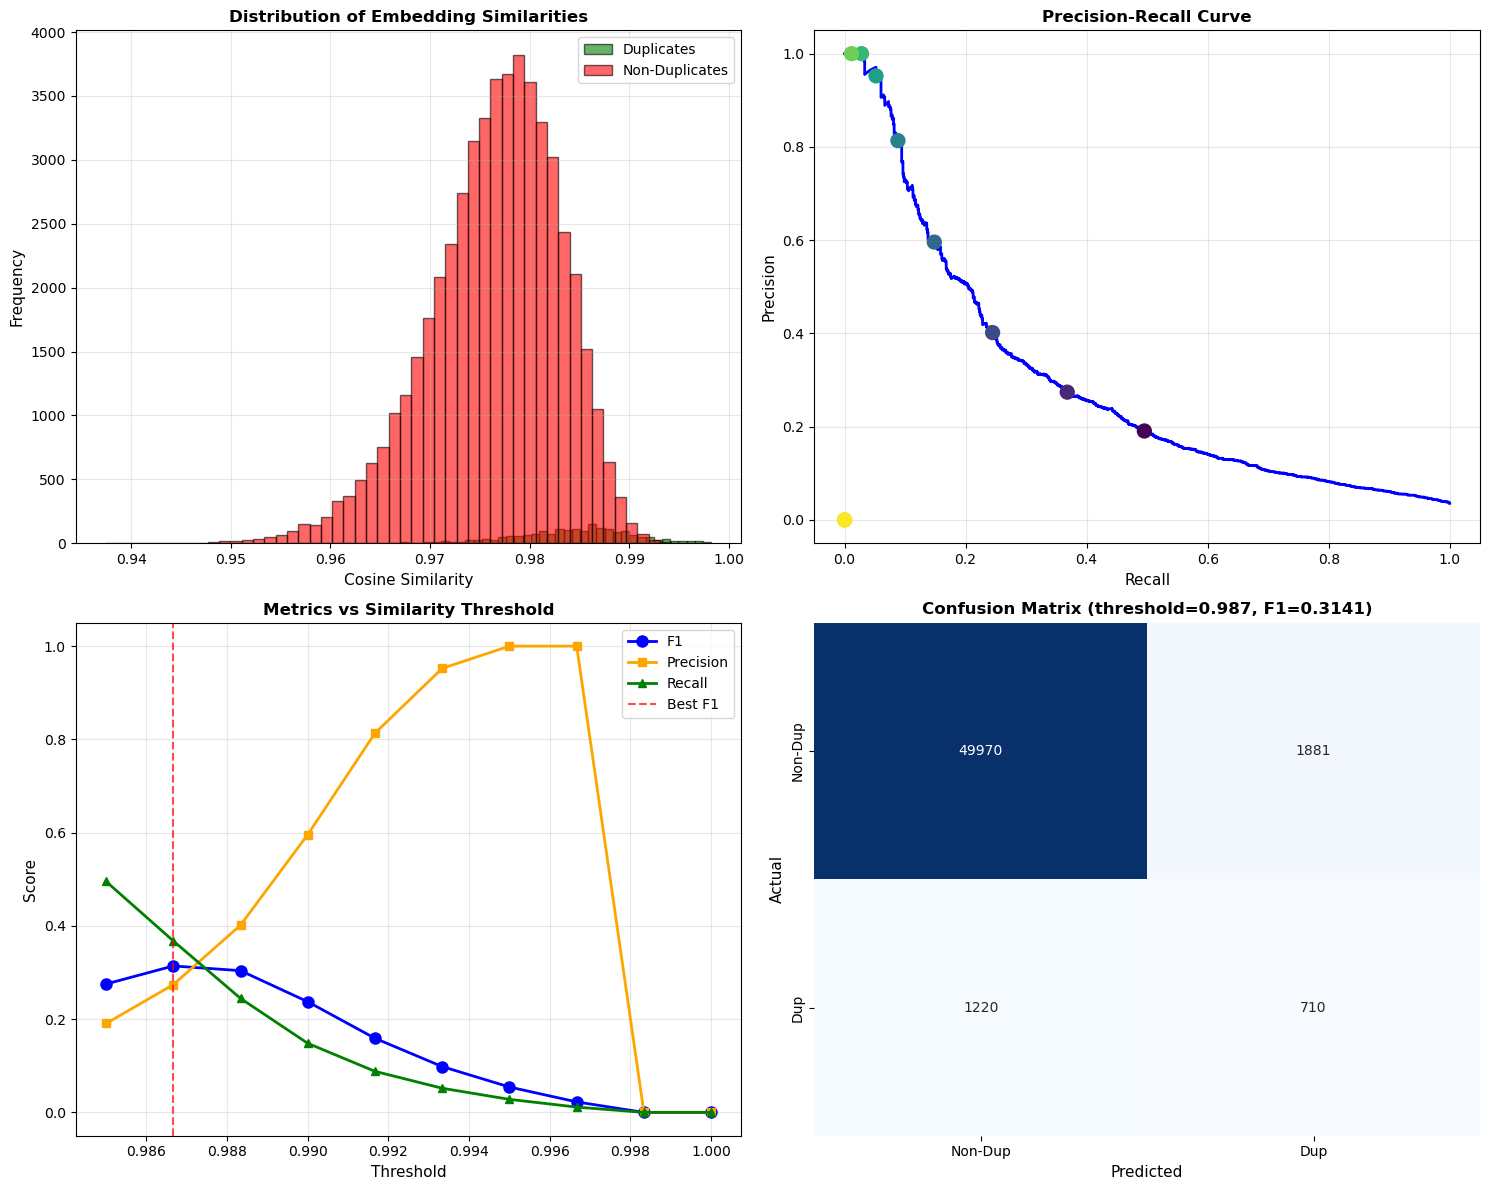


THRESHOLD EVALUATION RESULTS:
 Threshold  Precision   Recall       F1  Accuracy  TP   FP   FN    TN
  0.985000   0.190704 0.495337 0.275385  0.906454 956 4057  974 47794
  0.986667   0.274025 0.367876 0.314090  0.942340 710 1881 1220 49970
  0.988333   0.401702 0.244560 0.304026  0.959819 472  703 1458 51148
  0.990000   0.595833 0.148187 0.237344  0.965824 286  194 1644 51657
  0.991667   0.813397 0.088083 0.158953  0.966550 170   39 1760 51812
  0.993333   0.952381 0.051813 0.098280  0.965880 100    5 1830 51846
  0.995000   1.000000 0.027979 0.054435  0.965118  54    0 1876 51851
  0.996667   1.000000 0.011399 0.022541  0.964523  22    0 1908 51851
  0.998333   0.000000 0.000000 0.000000  0.964114   0    0 1930 51851
  1.000000   0.000000 0.000000 0.000000  0.964114   0    0 1930 51851
Evaluating embed_dim=64, output_dim=64
Model Configuration:
  vocab_size=38, embed_dim=64
  num_filters=128, kernel_sizes=(3, 4, 5)
  dropout=0.3, output_dim=64

1. Generating embeddings...
   ✓ Gene

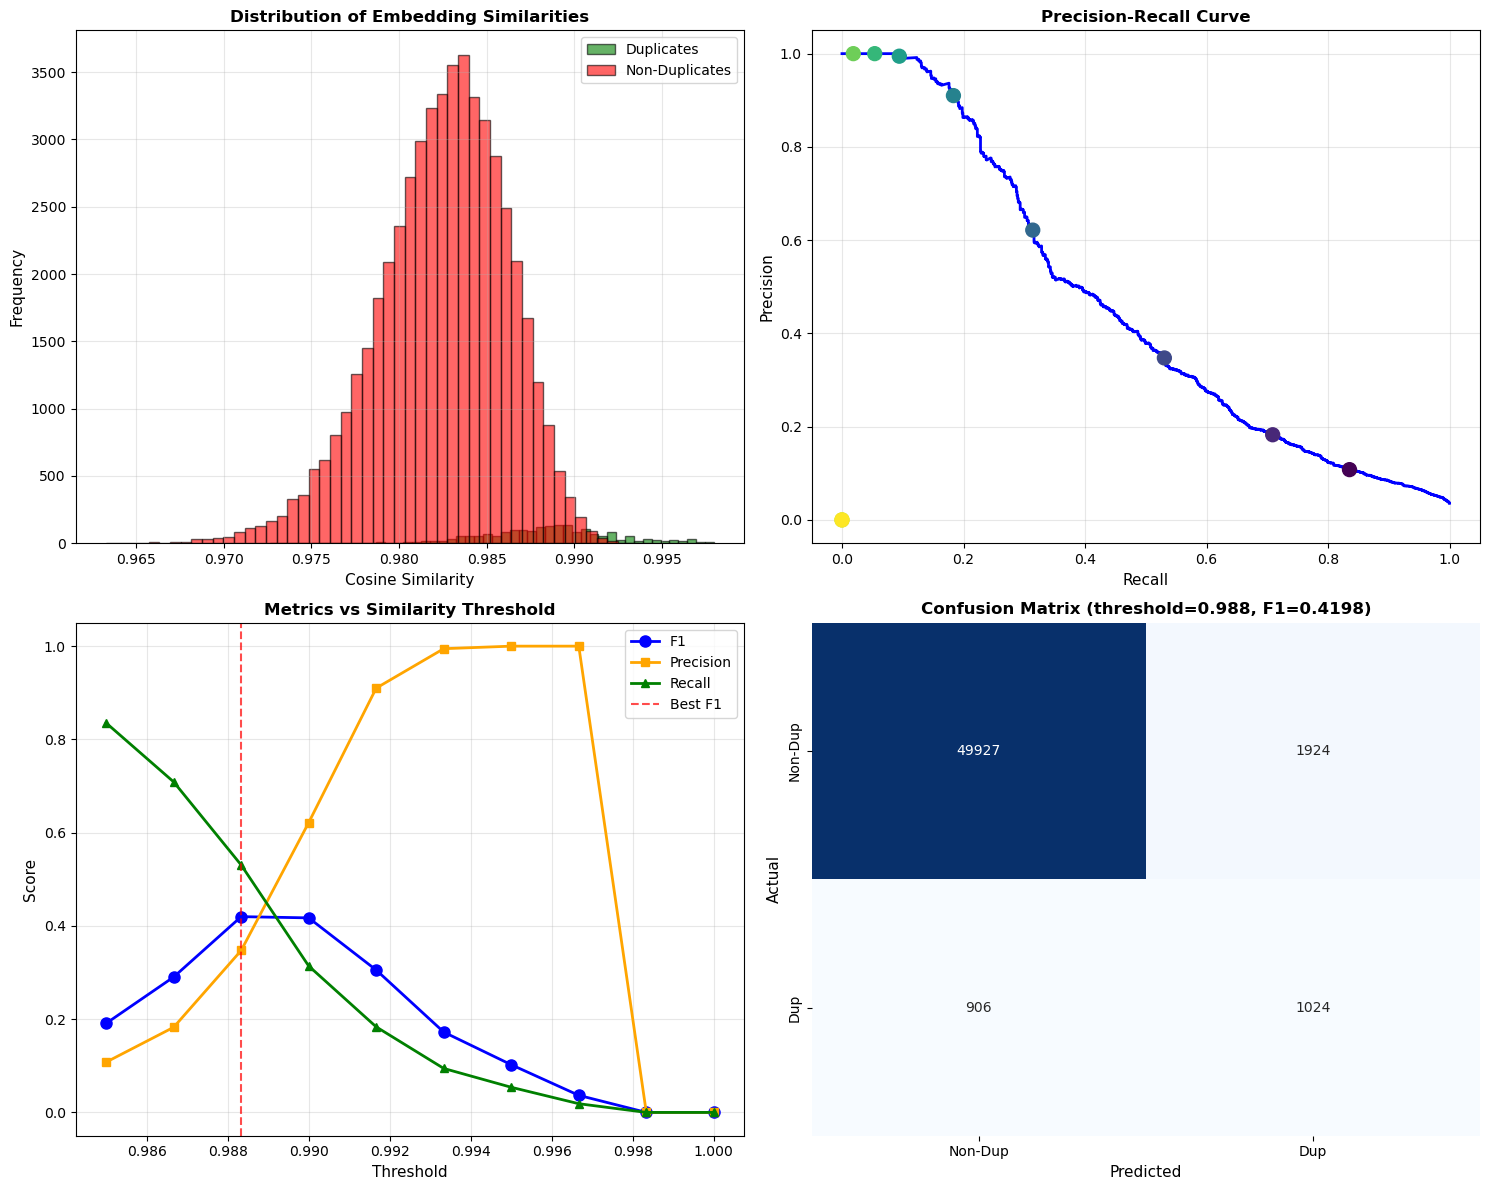


THRESHOLD EVALUATION RESULTS:
 Threshold  Precision   Recall       F1  Accuracy   TP    FP   FN    TN
  0.985000   0.107833 0.835233 0.191007  0.746100 1612 13337  318 38514
  0.986667   0.182619 0.708808 0.290415  0.875700 1368  6123  562 45728
  0.988333   0.347354 0.530570 0.419844  0.947379 1024  1924  906 49927
  0.990000   0.621538 0.313990 0.417212  0.968520  606   369 1324 51482
  0.991667   0.910026 0.183420 0.305304  0.970045  354    35 1576 51816
  0.993333   0.994536 0.094301 0.172267  0.967479  182     1 1748 51850
  0.995000   1.000000 0.053886 0.102262  0.966047  104     0 1826 51851
  0.996667   1.000000 0.018653 0.036623  0.964783   36     0 1894 51851
  0.998333   0.000000 0.000000 0.000000  0.964114    0     0 1930 51851
  1.000000   0.000000 0.000000 0.000000  0.964114    0     0 1930 51851
Evaluating embed_dim=64, output_dim=128
Model Configuration:
  vocab_size=38, embed_dim=64
  num_filters=128, kernel_sizes=(3, 4, 5)
  dropout=0.3, output_dim=128

1. Generating

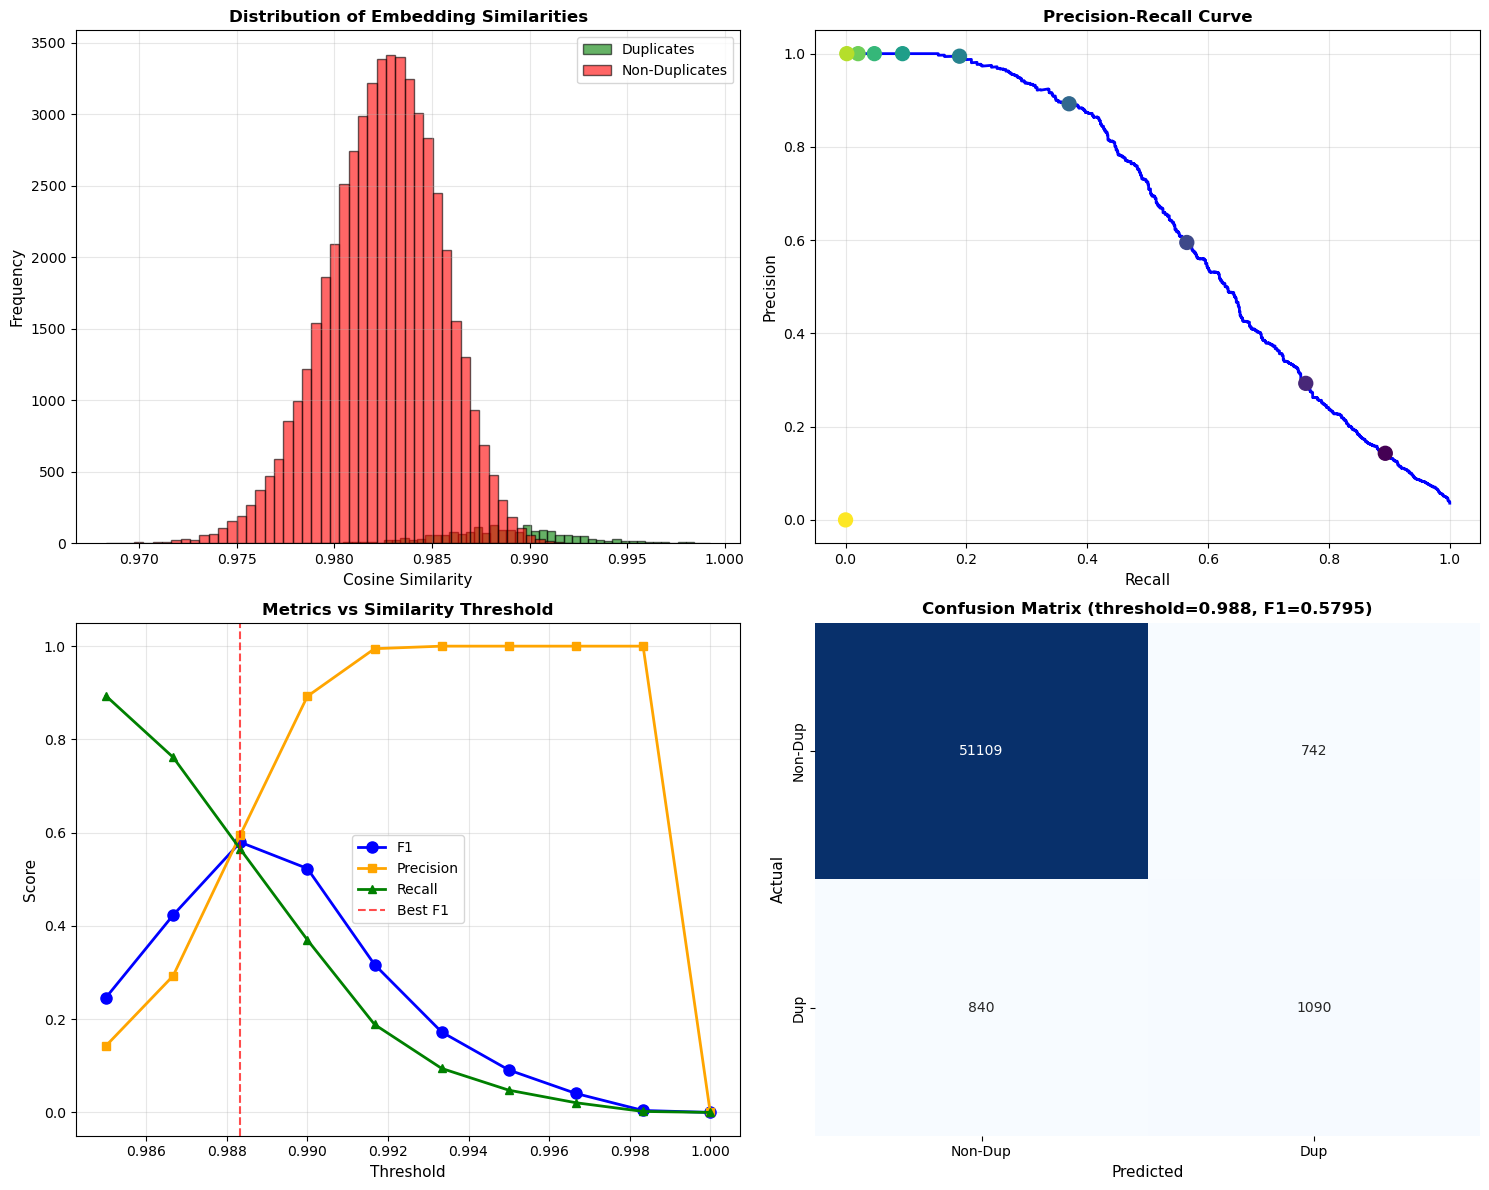


THRESHOLD EVALUATION RESULTS:
 Threshold  Precision   Recall       F1  Accuracy   TP    FP   FN    TN
  0.985000   0.142905 0.893264 0.246391  0.803908 1724 10340  206 41511
  0.986667   0.292887 0.761658 0.423082  0.925457 1470  3549  460 48302
  0.988333   0.594978 0.564767 0.579479  0.970584 1090   742  840 51109
  0.990000   0.892500 0.369948 0.523077  0.975791  714    86 1216 51765
  0.991667   0.994536 0.188601 0.317073  0.970845  364     2 1566 51849
  0.993333   1.000000 0.094301 0.172348  0.967498  182     0 1748 51851
  0.995000   1.000000 0.047668 0.090999  0.965824   92     0 1838 51851
  0.996667   1.000000 0.020725 0.040609  0.964857   40     0 1890 51851
  0.998333   1.000000 0.002073 0.004137  0.964188    4     0 1926 51851
  1.000000   0.000000 0.000000 0.000000  0.964114    0     0 1930 51851
F1 Scores Grid (embed_dim vs output_dim):
output_dim       16        32        64        128
embed_dim                                         
8           0.214060  0.259278  0

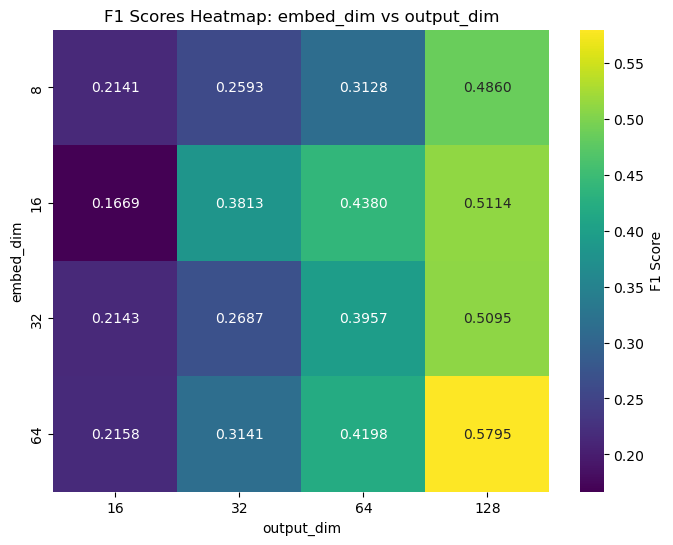

In [ ]:
import pandas as pd
import seaborn as sns
from sklearn.metrics import confusion_matrix, precision_recall_curve

import matplotlib.pyplot as plt

# Define the dimensions to test
embed_dims = [8, 16, 32, 64]
output_dims = [16, 32, 64, 128]

# Collect results in a list
results_list = []

for embed in embed_dims:
    for output in output_dims:
        print(f"Evaluating embed_dim={embed}, output_dim={output}")
        result = evaluate_model(
            ids_data=train_ids_data,
            pairs_data=train_last_name_pairs,
            vocab_size=38,
            embed_dim=embed,
            num_filters=128,
            kernel_sizes=(3, 4, 5),
            dropout=0.3,
            output_dim=output
        )
        results_list.append({
            'embed_dim': embed,
            'output_dim': output,
            'best_f1': result['best_f1']
        })

# Create a DataFrame from results
results_df = pd.DataFrame(results_list)

# Pivot to create a grid (embed_dim as rows, output_dim as columns)
f1_grid = results_df.pivot(index='embed_dim', columns='output_dim', values='best_f1')

# Display the grid as a table
print("F1 Scores Grid (embed_dim vs output_dim):")
print(f1_grid)

# Visualize as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(f1_grid, annot=True, fmt=".4f", cmap="viridis", cbar_kws={'label': 'F1 Score'})
plt.title('F1 Scores Heatmap: embed_dim vs output_dim')
plt.xlabel('output_dim')
plt.ylabel('embed_dim')
plt.show()

In [ ]:
# move to repo root (you are currently in /src)
%cd ..

# confirm branch, switch if needed
!git branch --show-current
!git checkout Arpith

# stage, commit, and push to Arpith
!git add -A
!git commit -m "Updated F1 score evaluations"
!git push origin Arpith

## Trying on the whole data

We apply the exact same thing on the entire data and see how F1 score changes

In [ ]:
%cd "C:\Users\arpit\spring-2026-deep-learning-fragmented-id-resolution"

C:\Users\arpit\spring-2026-deep-learning-fragmented-id-resolution


In [ ]:
train_data = pd.read_csv("data/train_pairs_aug.csv", delimiter=',')
val_data = pd.read_csv("data/val_pairs_aug.csv")

train_id1_data = train_data[
    ['id_1', 'first_name_1', 'midl_name_1', 'last_name_1', 'age_1', 'sex_1', 'area_cd_1', 'zip_code_1', 'street_name_1', 'house_num_1', 'area_cd_1']
].rename(columns={
    'id_1': 'id',
    'first_name_1': 'first_name',
    'midl_name_1': 'middle_name',
    'last_name_1': 'last_name',
    'age_1': 'age',
    'sex_1': 'sex',
    'area_cd_1': 'district',
    'zip_code_1': 'zipcode',
    'street_name_1': 'street',
    'house_num_1': 'house_num',
    'area_cd_1':'area_cd'
    
})

train_id2_data = train_data[
    ['id_2', 'first_name_2', 'midl_name_2', 'last_name_2', 'age_2', 'sex_2', 'area_cd_2', 'zip_code_2', 'street_name_2','house_num_2', 'area_cd_2']
].rename(columns={
    'id_2': 'id',
    'first_name_2': 'first_name',
    'midl_name_2': 'middle_name',
    'last_name_2': 'last_name',
    'age_2': 'age',
    'sex_2': 'sex',
    'area_cd_2': 'district',
    'zip_code_2': 'zipcode',
    'street_name_2': 'street',
    'house_num_2': 'house_num',
    'area_cd_2':'area_cd'
})

val_id1_data = val_data[
    ['id_1', 'first_name_1', 'midl_name_1', 'last_name_1', 'age_1', 'sex_1', 'area_cd_1', 'zip_code_1', 'street_name_1','house_num_1','area_cd_1']
].rename(columns={
    'id_1': 'id',
    'first_name_1': 'first_name',
    'midl_name_1': 'middle_name',
    'last_name_1': 'last_name',
    'age_1': 'age',
    'sex_1': 'sex',
    'area_cd_1': 'district',
    'zip_code_1': 'zipcode',
    'street_name_1': 'street',
    'house_num_1': 'house_num',
    'area_cd_1':'area_cd'
})

val_id2_data = val_data[
    ['id_2', 'first_name_2', 'midl_name_2', 'last_name_2', 'age_2', 'sex_2', 'area_cd_2', 'zip_code_2', 'street_name_2','house_num_2', 'area_cd_2']
].rename(columns={
    'id_2': 'id',
    'first_name_2': 'first_name',
    'midl_name_2': 'middle_name',
    'last_name_2': 'last_name',
    'age_2': 'age',
    'sex_2': 'sex',
    'area_cd_2': 'district',
    'zip_code_2': 'zipcode',
    'street_name_2': 'street',
    'house_num_2': 'house_num',
    'area_cd_2':'area_cd'
})

train_ids_data = pd.concat([train_id1_data, train_id2_data], ignore_index=True).drop_duplicates(subset=['id'], keep='first')
val_ids_data = pd.concat([val_id1_data, val_id2_data], ignore_index=True).drop_duplicates(subset=['id'], keep='first')

train_ids_data['middle_name'] = train_ids_data['middle_name'].fillna("")
val_ids_data['middle_name'] = val_ids_data['middle_name'].fillna("")

print(train_ids_data.head())
print(val_ids_data.head())
print(train_ids_data.columns.tolist())

         id first_name      middle_name   last_name  age     sex area_cd  \
0  11401396       eric           dwyane  winebarger   45    male     828   
1   3569312    semaje   alexis na quell      gordon   24  female     910   
4   9442163     samaje  alexis na quell      gordon   24  female           
6   9522852     semaje   alexis maquell      gordon   24  female     910   
7  12658910       mark          talbert    benfield   33    male           

  zipcode        street  house_num area_cd  
0   28139    poors ford       3151     828  
1   27713    cornwallis       1400     910  
4   28546       village        300          
6   28546    brynn marr       1220     910  
7   27519  fallen acorn       2202          
         id first_name middle_name last_name  age     sex area_cd  zipcode  \
0    299592   kimberly       marie     eadie   51  female            28451   
1  14061389    william      thomas      boyd   69    male     252    27893   
2  13774208  francisco     alberto     

C:\Users\arpit\AppData\Local\Temp\ipykernel_61132\1942755719.py:1: DtypeWarning: Columns (42) have mixed types. Specify dtype option on import or set low_memory=False.
  train_data = pd.read_csv("data/train_pairs_aug.csv", delimiter=',')


In [ ]:
# Create full pairs dataframe with labels
train_pairs_full = train_data[['id_1', 'id_2', 'label']].rename(columns={'id_1': 'id1', 'id_2': 'id2'})
val_pairs_full = val_data[['id_1', 'id_2', 'label']].rename(columns={'id_1': 'id1', 'id_2': 'id2'})

print(f"Full training pairs: {len(train_pairs_full)}")
print(f"  Duplicates: {(train_pairs_full['label'] == 1).sum()}")
print(f"  Non-duplicates: {(train_pairs_full['label'] == 0).sum()}")
print(f"\nFull validation pairs: {len(val_pairs_full)}")
print(f"  Duplicates: {(val_pairs_full['label'] == 1).sum()}")
print(f"  Non-duplicates: {(val_pairs_full['label'] == 0).sum()}")


In [ ]:
# Grid search over embedding dimensions on FULL augmented data
print("\n" + "="*70)
print("GRID SEARCH: Embedding vs Output Dimensions (FULL AUGMENTED DATA)")
print("="*70)

embed_dims = [8, 16, 32, 64]
output_dims = [16, 32, 64, 128]

results_list_full = []

for embed in embed_dims:
    for output in output_dims:
        print(f"\n{'='*70}")
        print(f"Testing embed_dim={embed}, output_dim={output}")
        print(f"{'='*70}")
        
        result = evaluate_model(
            ids_data=train_ids_data,
            pairs_data=train_pairs_full,
            vocab_size=38,
            embed_dim=embed,
            num_filters=128,
            kernel_sizes=(3, 4, 5),
            dropout=0.3,
            output_dim=output
        )
        
        results_list_full.append({
            'embed_dim': embed,
            'output_dim': output,
            'best_f1': result['best_f1'],
            'best_threshold': result['best_threshold']
        })
        
        print(f"\n✓ Best F1: {result['best_f1']:.4f} at threshold {result['best_threshold']:.4f}")

# Create results dataframe
results_df_full = pd.DataFrame(results_list_full)

# Pivot to create a grid
f1_grid_full = results_df_full.pivot(index='embed_dim', columns='output_dim', values='best_f1')

print("\n" + "="*70)
print("F1 SCORES GRID - FULL AUGMENTED DATA (embed_dim vs output_dim):")
print("="*70)
print(f1_grid_full)

# Visualize as heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(f1_grid_full, annot=True, fmt=".4f", cmap="viridis", 
            cbar_kws={'label': 'F1 Score'}, linewidths=0.5)
plt.title('F1 Scores Heatmap: Full Augmented Data\n(embed_dim vs output_dim)', 
          fontsize=14, fontweight='bold')
plt.xlabel('output_dim', fontsize=12)
plt.ylabel('embed_dim', fontsize=12)
plt.tight_layout()
plt.savefig('f1_grid_full_augmented.png', dpi=150, bbox_inches='tight')
plt.show()

# Show best configuration
best_idx = results_df_full['best_f1'].idxmax()
best_config = results_df_full.loc[best_idx]
print(f"\n{'='*70}")
print("BEST CONFIGURATION (FULL DATA):")
print(f"{'='*70}")
print(f"  embed_dim: {int(best_config['embed_dim'])}")
print(f"  output_dim: {int(best_config['output_dim'])}")
print(f"  Best F1: {best_config['best_f1']:.4f}")
print(f"  Best Threshold: {best_config['best_threshold']:.4f}")
print(f"{'='*70}")



GRID SEARCH: Embedding vs Output Dimensions (FULL AUGMENTED DATA)

Testing embed_dim=8, output_dim=16


NameError: name 'train_pairs_full' is not defined